# TFM — Fase 1: Exploración de MIMIC-III Clinical Database Demo v1.4
**Autor:** Pablo Federico Martín Luna  
**Máster:** Inteligencia Artificial — UNIR  
**Objetivo:** Análisis exploratorio de CHARTEVENTS para seleccionar señales, validar
densidad temporal y determinar la arquitectura del modelo base.  
**Semilla:** `SEED = 42` (reproducibilidad garantizada en todos los bloques)  

---
## Bloques
1. Configuración del entorno y rutas  
2. Carga y vista general de CHARTEVENTS  
3. Disponibilidad de señales vitales (ITEMIDs objetivo)  
4. Densidad temporal y cobertura por paciente  
5. Análisis de valores ausentes  
6. Validación de rangos fisiológicos  
7. Análisis de tamaño de ventana temporal  
8. Síntesis y decisión de arquitectura  

---
## BLOQUE 1 — Configuración del entorno y rutas
Se fija la semilla global y se definen las rutas al dataset de MIMIC-III.
Ajusta `BASE_PATH` si el dataset está en otra ubicación dentro de Kaggle.

In [4]:
# ============================================================
# BLOQUE 1 — Configuración del entorno y rutas
# ============================================================
# Por qué: establecer reproducibilidad y rutas antes de cualquier
# operación garantiza que todos los bloques posteriores sean
# independientes del entorno local del ejecutor.

import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')

# -- Semilla global --
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# -- Ruta base al dataset MIMIC-III Demo v1.4 en Kaggle --
# Si lo has subido como dataset propio, ajusta la ruta.
BASE_PATH = '/kaggle/input/datasets/montassarba/mimic-iii-clinical-database-demo-1-4/mimic-iii-clinical-database-demo-1.4'

# Verificar que el directorio existe
if not os.path.exists(BASE_PATH):
    raise FileNotFoundError(
        f"Dataset no encontrado en {BASE_PATH}. "
        "Verifica que el dataset MIMIC-III Demo v1.4 está añadido "
        "a este notebook en Kaggle."
    )

# Listar archivos disponibles
archivos = sorted(os.listdir(BASE_PATH))
print(f"Archivos encontrados ({len(archivos)}):")
for f in archivos:
    ruta = os.path.join(BASE_PATH, f)
    tamanio_mb = os.path.getsize(ruta) / (1024 * 1024)
    print(f"  {f:<40} {tamanio_mb:>8.2f} MB")

# Estilo global de gráficas
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.figsize': (12, 4),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})
sns.set_palette('muted')

print("\nEntorno configurado correctamente. SEED =", SEED)

Archivos encontrados (28):
  ADMISSIONS.csv                               0.03 MB
  CALLOUT.csv                                  0.01 MB
  CAREGIVERS.csv                               0.17 MB
  CHARTEVENTS.csv                             74.13 MB
  CPTEVENTS.csv                                0.14 MB
  DATETIMEEVENTS.csv                           1.70 MB
  DIAGNOSES_ICD.csv                            0.05 MB
  DRGCODES.csv                                 0.02 MB
  D_CPT.csv                                    0.01 MB
  D_ICD_DIAGNOSES.csv                          1.25 MB
  D_ICD_PROCEDURES.csv                         0.28 MB
  D_ITEMS.csv                                  0.81 MB
  D_LABITEMS.csv                               0.04 MB
  ICUSTAYS.csv                                 0.01 MB
  INPUTEVENTS_CV.csv                           4.52 MB
  INPUTEVENTS_MV.csv                           3.23 MB
  LABEVENTS.csv                                4.54 MB
  LICENSE.txt                         

---
## BLOQUE 2 — Carga y vista general de CHARTEVENTS
CHARTEVENTS es la tabla principal: contiene todas las mediciones de constantes
vitales registradas en UCI. Dado su tamaño, se carga en chunks para controlar
el uso de memoria.

In [5]:
# ============================================================
# BLOQUE 2 — Carga y vista general de CHARTEVENTS
# ============================================================
# Por qué: CHARTEVENTS puede tener millones de filas en la versión
# completa. En el demo (100 pacientes) es manejable, pero se carga
# con tipos explícitos para reducir RAM y acelerar la carga.

CHARTEVENTS_PATH = os.path.join(BASE_PATH, 'CHARTEVENTS.csv')

dtype_chart = {
    'row_id':      'int32',
    'subject_id':  'int32',
    'hadm_id':     'float32',
    'icustay_id':  'float32',
    'itemid':      'int32',
    'cgid':        'float32',
    'value':       'object',
    'valuenum':    'float32',
    'valueuom':    'object',
    'warning':     'float32',
    'error':       'float32',
    'resultstatus':'object',
    'stopped':     'object'
}

print("Cargando CHARTEVENTS...")
chart = pd.read_csv(
    CHARTEVENTS_PATH,
    dtype=dtype_chart,
    parse_dates=['charttime', 'storetime'],
    low_memory=False
)

print(f"\nDimensiones: {chart.shape[0]:,} filas × {chart.shape[1]} columnas")
print(f"Pacientes únicos:       {chart['subject_id'].nunique()}")
print(f"Estancias UCI únicas:   {chart['icustay_id'].nunique():.0f}")
print(f"ITEMIDs únicos:         {chart['itemid'].nunique():,}")
print(f"\nRango temporal:")
print(f"  Desde: {chart['charttime'].min()}")
print(f"  Hasta: {chart['charttime'].max()}")

print("\nVista de las primeras 5 filas:")
display(chart.head())

info = pd.DataFrame({
    'dtype':   chart.dtypes,
    'nulos':   chart.isnull().sum(),
    'nulos_%': (chart.isnull().sum() / len(chart) * 100).round(2)
})
print("\nTipos de datos y nulos:")
display(info)

Cargando CHARTEVENTS...

Dimensiones: 758,355 filas × 15 columnas
Pacientes únicos:       99
Estancias UCI únicas:   133
ITEMIDs únicos:         1,679

Rango temporal:
  Desde: 2102-08-31 17:00:00
  Hasta: 2202-05-02 22:27:00

Vista de las primeras 5 filas:


,row_id,subject_id,hadm_id,icustay_id,itemid,charttime,storetime,cgid,value,valuenum,valueuom,warning,error,resultstatus,stopped
0,5279021,40124,126179.0,279554.0,223761,2130-02-04 04:00:00,2130-02-04 04:35:00,19085.0,95.9,9.590000e+01,?F,0.0,0.0,NaN,NaN
1,5279022,40124,126179.0,279554.0,224695,2130-02-04 04:25:00,2130-02-04 05:55:00,18999.0,2222221.7,2.222222e+06,cmH2O,0.0,0.0,NaN,NaN
2,5279023,40124,126179.0,279554.0,220210,2130-02-04 04:30:00,2130-02-04 04:43:00,21452.0,15,1.500000e+01,insp/min,0.0,0.0,NaN,NaN
3,5279024,40124,126179.0,279554.0,220045,2130-02-04 04:32:00,2130-02-04 04:43:00,21452.0,94,9.400000e+01,bpm,0.0,0.0,NaN,NaN
4,5279025,40124,126179.0,279554.0,220179,2130-02-04 04:32:00,2130-02-04 04:43:00,21452.0,163,1.630000e+02,mmHg,0.0,0.0,NaN,NaN



Tipos de datos y nulos:


,dtype,nulos,nulos_%
row_id,int32,0,0.00
subject_id,int32,0,0.00
hadm_id,float32,0,0.00
icustay_id,float32,81,0.01
itemid,int32,0,0.00
charttime,datetime64[ns],0,0.00
storetime,datetime64[ns],0,0.00
cgid,float32,0,0.00
value,object,32848,4.33
valuenum,float32,434471,57.29


---
## BLOQUE 3 — Disponibilidad de señales vitales (ITEMIDs objetivo)
Se mapean los ITEMIDs de las 7 señales vitales definidas en el protocolo del TFM
y se cuantifica su presencia en el dataset.

Disponibilidad de señales vitales en CHARTEVENTS:


,Señal,Registros,Pacientes,Cobertura (%),Estancias UCI
0,Heart Rate,15485,98,99.0,132
3,SpO2,15300,98,99.0,132
5,Respiratory Rate,15086,98,99.0,132
6,MAP,10976,69,69.7,81
1,SBP,7818,50,50.5,56
2,DBP,7816,50,50.5,56
4,Temperature (C),2698,49,49.5,58


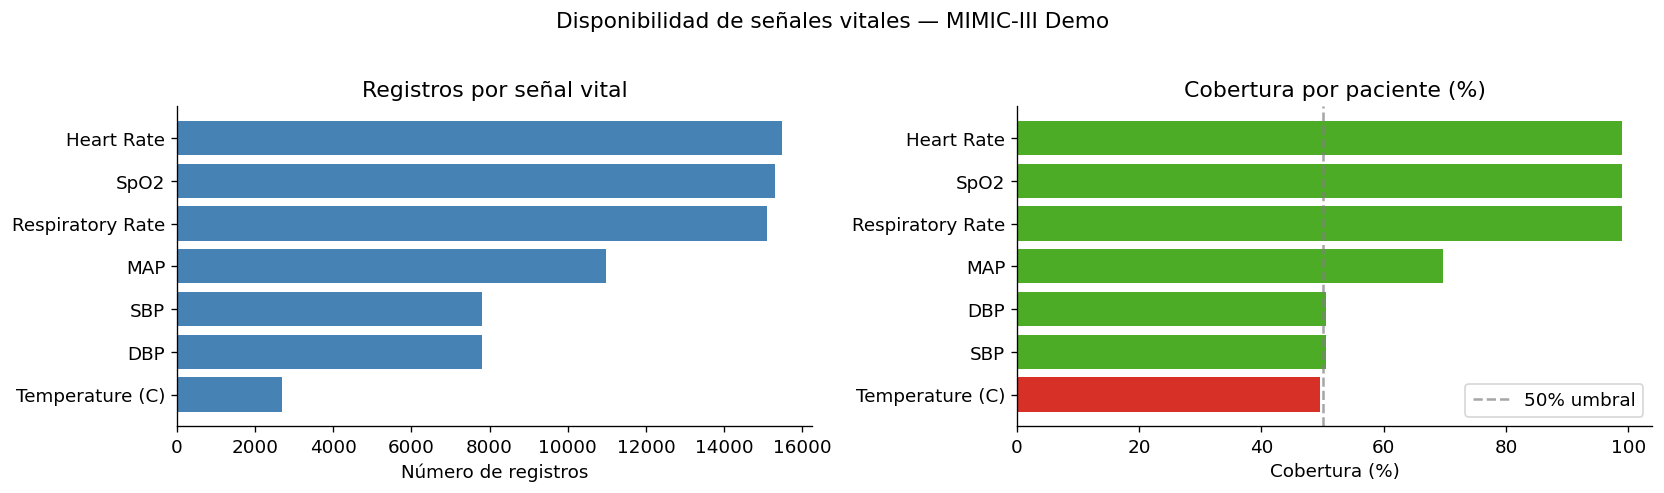


Señales con cobertura >= 50%: ['Heart Rate', 'SpO2', 'Respiratory Rate', 'MAP', 'SBP', 'DBP']


In [6]:
# ============================================================
# BLOQUE 3 — Disponibilidad de señales vitales
# ============================================================
# Por qué: el protocolo del TFM define 7 señales objetivo.
# Es necesario verificar que existen en suficiente cantidad
# antes de comprometer la arquitectura del modelo.
# Los ITEMIDs provienen del sistema CareVue (200-299) y
# MetaVision (220-229) de MIMIC-III.

SENALES = {
    'Heart Rate':        [211, 220045],
    'SBP':               [51, 220050, 225309],
    'DBP':               [8368, 220051, 225310],
    'SpO2':              [646, 220277],
    'Temperature (C)':   [676, 677, 223762],
    'Respiratory Rate':  [618, 220210],
    'MAP':               [52, 456, 220052, 225312]
}

chart_num = chart[chart['valuenum'].notna()].copy()

resultados = []
for senal, itemids in SENALES.items():
    mask = chart_num['itemid'].isin(itemids)
    subset = chart_num[mask]
    n_registros  = len(subset)
    n_pacientes  = subset['subject_id'].nunique()
    n_estancias  = subset['icustay_id'].nunique()
    cobertura_pct = n_pacientes / chart['subject_id'].nunique() * 100
    resultados.append({
        'Señal':          senal,
        'ITEMIDs':        itemids,
        'Registros':      n_registros,
        'Pacientes':      n_pacientes,
        'Cobertura (%)':  round(cobertura_pct, 1),
        'Estancias UCI':  int(n_estancias)
    })

df_disponibilidad = pd.DataFrame(resultados).sort_values('Registros', ascending=False)
print("Disponibilidad de señales vitales en CHARTEVENTS:")
display(df_disponibilidad.drop(columns='ITEMIDs'))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_disp_sorted = df_disponibilidad.sort_values('Registros')
axes[0].barh(df_disp_sorted['Señal'], df_disp_sorted['Registros'], color='steelblue')
axes[0].set_xlabel('Número de registros')
axes[0].set_title('Registros por señal vital')

df_cob_sorted = df_disponibilidad.sort_values('Cobertura (%)')
colors = ['#d73027' if x < 50 else '#4dac26' for x in df_cob_sorted['Cobertura (%)']]
axes[1].barh(df_cob_sorted['Señal'], df_cob_sorted['Cobertura (%)'], color=colors)
axes[1].axvline(50, color='gray', linestyle='--', alpha=0.7, label='50% umbral')
axes[1].set_xlabel('Cobertura (%)')
axes[1].set_title('Cobertura por paciente (%)')
axes[1].legend()

plt.suptitle('Disponibilidad de señales vitales — MIMIC-III Demo', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('bloque3_disponibilidad_senales.png', bbox_inches='tight')
plt.show()

SENALES_VALIDAS = [
    row['Señal'] for _, row in df_disponibilidad.iterrows()
    if row['Cobertura (%)'] >= 50
]
print(f"\nSeñales con cobertura >= 50%: {SENALES_VALIDAS}")

---
## BLOQUE 4 — Densidad temporal y cobertura por paciente
Se analiza la frecuencia de muestreo real de cada señal para determinar
si es suficiente para construir series temporales continuas.

Calculando intervalos temporales... (puede tardar 1-2 min)

Densidad temporal por señal:


,n_pacientes,mediana_intervalo_min,p90_intervalo_min,mediana_n_registros
senal,,,,
DBP,49,60.0,60.0,71.0
Heart Rate,98,60.0,60.0,61.5
MAP,69,60.0,60.0,69.0
Respiratory Rate,97,60.0,60.0,61.0
SBP,49,60.0,60.0,71.0
SpO2,98,60.0,60.0,56.5
Temperature (C),48,240.0,300.0,19.5


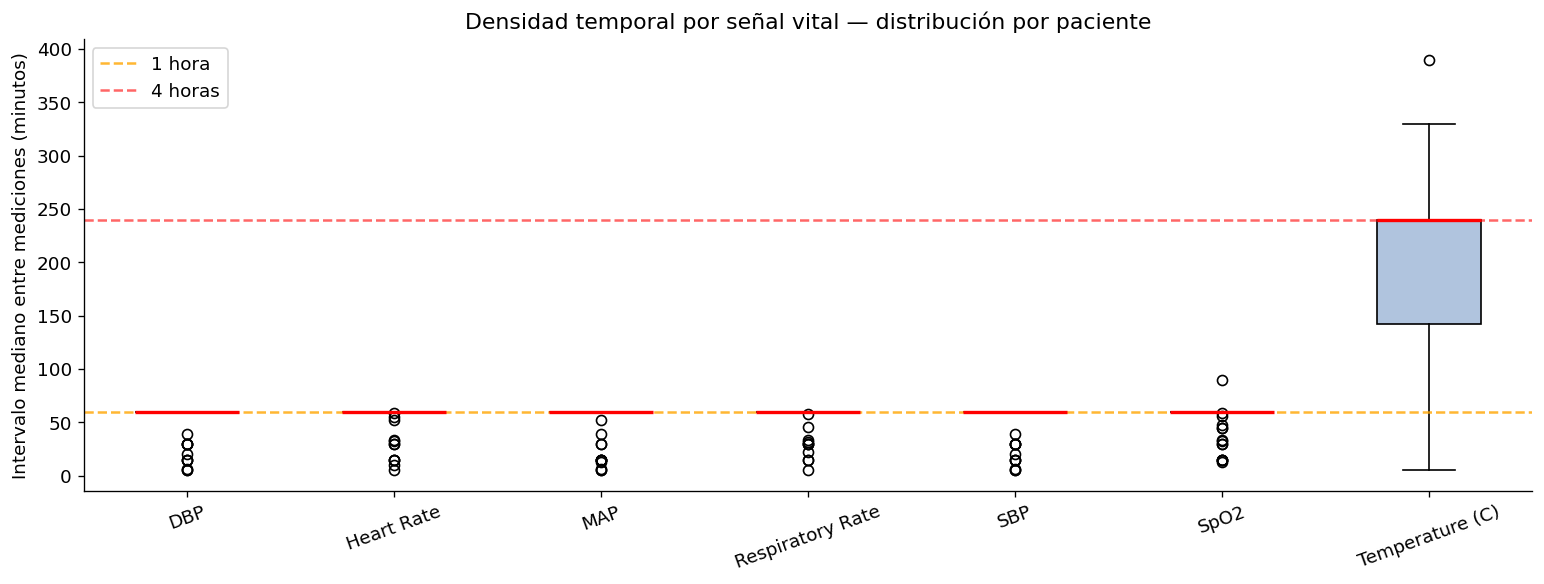


Interpretación:
  < 60 min  → muestreo horario o más frecuente → adecuada para ventanas 4-8h
  60-240 min → muestreo infra-horario → requiere interpolación
  > 240 min  → señal esporádica → posible exclusión


In [7]:
# ============================================================
# BLOQUE 4 — Densidad temporal y cobertura por paciente
# ============================================================
# Por qué: un modelo de detección de anomalías en series temporales
# requiere densidad de muestreo suficiente. Si la frecuencia media
# es demasiado baja o irregular, la interpolación introduce artefactos
# que pueden confundirse con anomalías.

todos_itemids = [iid for s in SENALES.values() for iid in s]
chart_vitals = chart_num[chart_num['itemid'].isin(todos_itemids)].copy()

itemid_to_senal = {}
for senal, itemids in SENALES.items():
    for iid in itemids:
        itemid_to_senal[iid] = senal
chart_vitals['senal'] = chart_vitals['itemid'].map(itemid_to_senal)

print("Calculando intervalos temporales... (puede tardar 1-2 min)")

intervalos = []
for (subject_id, senal), grupo in chart_vitals.groupby(['subject_id', 'senal']):
    tiempos = grupo['charttime'].sort_values()
    if len(tiempos) < 2:
        continue
    diffs = tiempos.diff().dropna().dt.total_seconds() / 60
    diffs = diffs[diffs > 0]
    if len(diffs) == 0:
        continue
    intervalos.append({
        'subject_id':           subject_id,
        'senal':                senal,
        'n_registros':          len(tiempos),
        'intervalo_median_min': diffs.median(),
        'intervalo_mean_min':   diffs.mean(),
        'intervalo_p90_min':    diffs.quantile(0.9)
    })

df_intervalos = pd.DataFrame(intervalos)

resumen_intervalos = df_intervalos.groupby('senal').agg(
    n_pacientes=('subject_id', 'nunique'),
    mediana_intervalo_min=('intervalo_median_min', 'median'),
    p90_intervalo_min=('intervalo_p90_min', 'median'),
    mediana_n_registros=('n_registros', 'median')
).round(1).sort_values('mediana_intervalo_min')

print("\nDensidad temporal por señal:")
display(resumen_intervalos)

fig, ax = plt.subplots(figsize=(13, 5))
senales_orden = resumen_intervalos.index.tolist()
data_box = [df_intervalos[df_intervalos['senal'] == s]['intervalo_median_min'].values
            for s in senales_orden]
bp = ax.boxplot(data_box, labels=senales_orden, patch_artist=True,
                medianprops=dict(color='red', linewidth=2))
for patch in bp['boxes']:
    patch.set_facecolor('lightsteelblue')
ax.axhline(60,  color='orange', linestyle='--', alpha=0.8, label='1 hora')
ax.axhline(240, color='red',    linestyle='--', alpha=0.6, label='4 horas')
ax.set_ylabel('Intervalo mediano entre mediciones (minutos)')
ax.set_title('Densidad temporal por señal vital — distribución por paciente')
ax.legend()
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('bloque4_densidad_temporal.png', bbox_inches='tight')
plt.show()

print("\nInterpretación:")
print("  < 60 min  → muestreo horario o más frecuente → adecuada para ventanas 4-8h")
print("  60-240 min → muestreo infra-horario → requiere interpolación")
print("  > 240 min  → señal esporádica → posible exclusión")

---
## BLOQUE 5 — Análisis de valores ausentes
Se cuantifica el porcentaje de ausentes por señal y se evalúa
la estrategia de imputación más adecuada.

Construyendo grilla horaria por paciente...
Ausentes por señal (grilla horaria):


,pct_ausentes_mediana,pct_ausentes_p90,gap_max_mediano
senal,,,
Temperature (C),72.8,82.7,7.0
MAP,5.2,49.1,1.0
SpO2,5.1,71.7,1.5
Respiratory Rate,4.4,74.4,1.0
Heart Rate,3.5,72.1,1.0
DBP,1.6,28.4,1.0
SBP,1.6,28.4,1.0


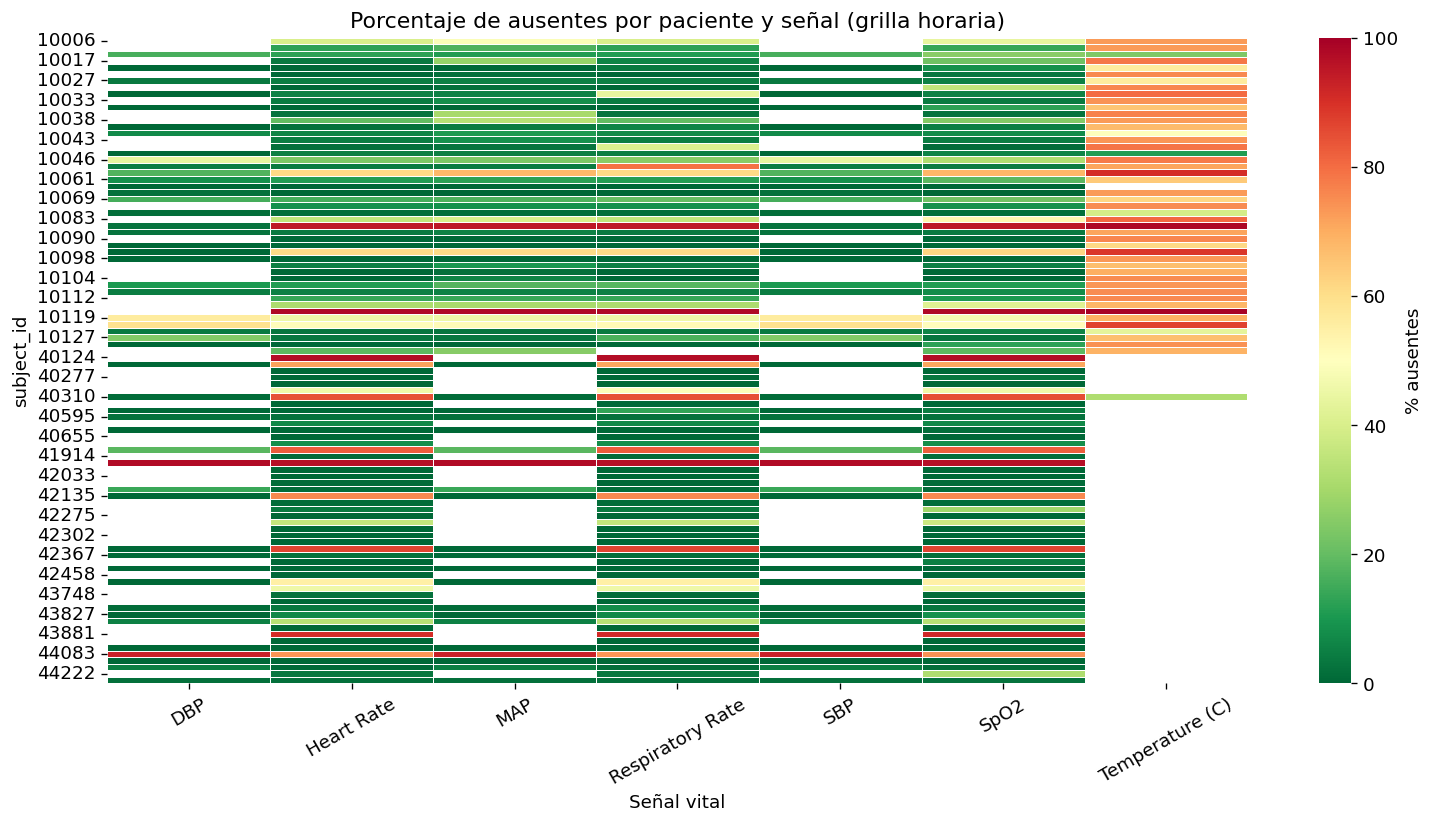


Umbral gap máximo tolerable: 4 horas
Registros que exceden el gap máximo: 32.7%
Estrategia: forward-fill hasta 4h; excluir ventanas con gap mayor.


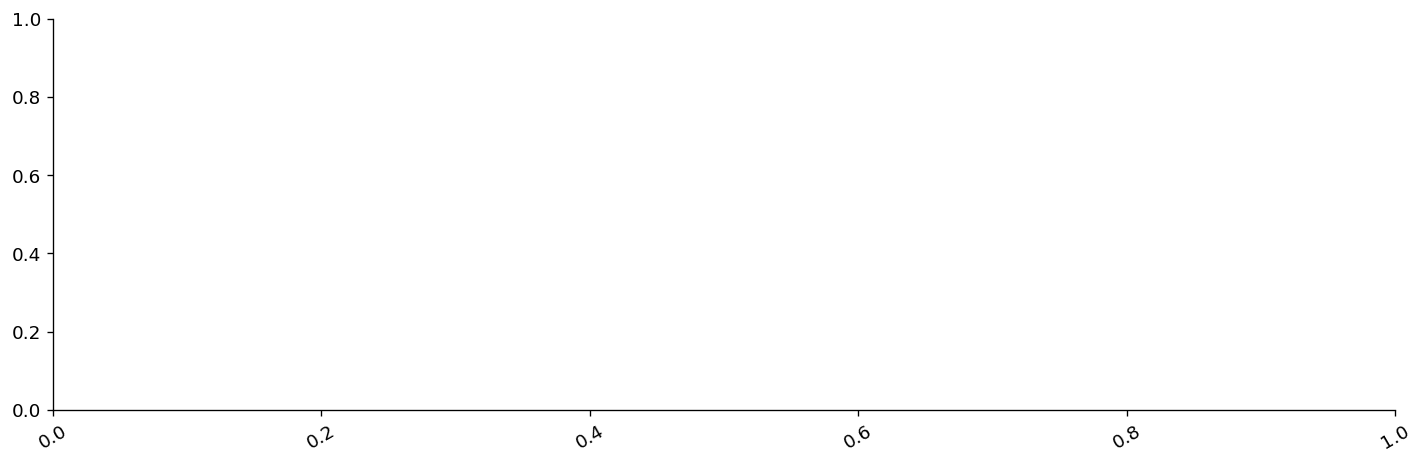


Umbral de gap máximo tolerable: 4 horas
Porcentaje de registros que exceden el gap máximo: 32.7%
Estrategia recomendada: forward-fill hasta 4 horas; excluir ventanas con gap mayor.


In [8]:
# ============================================================
# BLOQUE 5 — Análisis de valores ausentes
# ============================================================
# Por qué: la tasa de ausentes en CHARTEVENTS no es aleatoria —
# los registros faltan porque no se midió, no porque se perdió.
# Esto determina la estrategia de preprocesamiento: forward-fill
# es apropiado para constantes fisiológicas que caombian lentamente;
# la interpolación lineal puede introducir artefactos si el gap
# es largo. Se define umbral de gap máximo tolerable.

VENTANA_RESAMPLE = '1h'
GAP_MAX_HORAS   = 4

print("Construyendo grilla horaria por paciente...")

ausentes_paciente = []

for subject_id in chart_vitals['subject_id'].unique():
    pac = chart_vitals[chart_vitals['subject_id'] == subject_id].copy()
    pac = pac.set_index('charttime').sort_index()

    for senal in SENALES.keys():
        subset = pac[pac['senal'] == senal]['valuenum']
        if len(subset) < 2:
            continue

        serie = subset.resample(VENTANA_RESAMPLE).median()
        n_total    = len(serie)
        n_ausentes = serie.isnull().sum()
        pct_ausentes = n_ausentes / n_total * 100 if n_total > 0 else 0

        # Calcular gap máximo de nulos consecutivos
        gaps = []
        contador = 0
        for v in serie.values:
            if pd.isna(v):
                contador += 1
            else:
                if contador > 0:
                    gaps.append(contador)
                contador = 0
        if contador > 0:
            gaps.append(contador)

        ausentes_paciente.append({
            'subject_id':    subject_id,
            'senal':         senal,
            'n_total_horas': n_total,
            'pct_ausentes':  round(pct_ausentes, 1),
            'gap_max_horas': max(gaps) if gaps else 0
        })

df_ausentes = pd.DataFrame(ausentes_paciente)

resumen_ausentes = df_ausentes.groupby('senal').agg(
    pct_ausentes_mediana=('pct_ausentes', 'median'),
    pct_ausentes_p90=('pct_ausentes', lambda x: x.quantile(0.9)),
    gap_max_mediano=('gap_max_horas', 'median')
).round(1).sort_values('pct_ausentes_mediana', ascending=False)

print("Ausentes por señal (grilla horaria):")
display(resumen_ausentes)

pivot_ausentes = df_ausentes.pivot_table(
    index='subject_id',
    columns='senal',
    values='pct_ausentes',
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(
    pivot_ausentes,
    cmap='RdYlGn_r',
    vmin=0,
    vmax=100,
    linewidths=0.3,
    ax=ax,
    cbar_kws={'label': '% ausentes'}
)
ax.set_title('Porcentaje de ausentes por paciente y señal (grilla horaria)')
ax.set_xlabel('Señal vital')
ax.set_ylabel('subject_id')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('bloque5_ausentes_heatmap.png', bbox_inches='tight')
plt.show()

print(f"\nUmbral gap máximo tolerable: {GAP_MAX_HORAS} horas")
pct_exceden = (df_ausentes['gap_max_horas'] > GAP_MAX_HORAS).mean() * 100
print(f"Registros que exceden el gap máximo: {pct_exceden:.1f}%")
print(f"Estrategia: forward-fill hasta {GAP_MAX_HORAS}h; excluir ventanas con gap mayor.")
ax.set_title('Porcentaje de ausentes por paciente y señal (grilla horaria)')
ax.set_xlabel('Señal vital')
ax.set_ylabel('SUBJECT_ID')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('bloque5_ausentes_heatmap.png', bbox_inches='tight')
plt.show()

print(f"\nUmbral de gap máximo tolerable: {GAP_MAX_HORAS} horas")
pct_exceden = (df_ausentes['gap_max_horas'] > GAP_MAX_HORAS).mean() * 100
print(f"Porcentaje de registros que exceden el gap máximo: {pct_exceden:.1f}%")
print("Estrategia recomendada: forward-fill hasta", GAP_MAX_HORAS,
      "horas; excluir ventanas con gap mayor.")

---
## BLOQUE 6 — Validación de rangos fisiológicos
Se detectan valores fuera de rango clínico para decidir si filtrarlos
o usarlos como anomalías positivas en el protocolo de evaluación.

Validación de rangos fisiológicos:


,Señal,Total registros,Rango normal,Errores (hard-limit),Anomalías clínicas,% errores,% anomalías
0,Heart Rate,15485,"[40, 140]",0,121,0.00,0.78
1,SBP,7818,"[70, 200]",0,115,0.00,1.47
2,DBP,7816,"[40, 120]",0,365,0.00,4.67
3,SpO2,15300,"[85, 100]",0,194,0.00,1.27
4,Temperature (C),2698,"[35.5, 38.5]",0,228,0.00,8.45
5,Respiratory Rate,15086,"[8, 30]",2,1307,0.01,8.66
6,MAP,10976,"[50, 130]",13,303,0.12,2.76


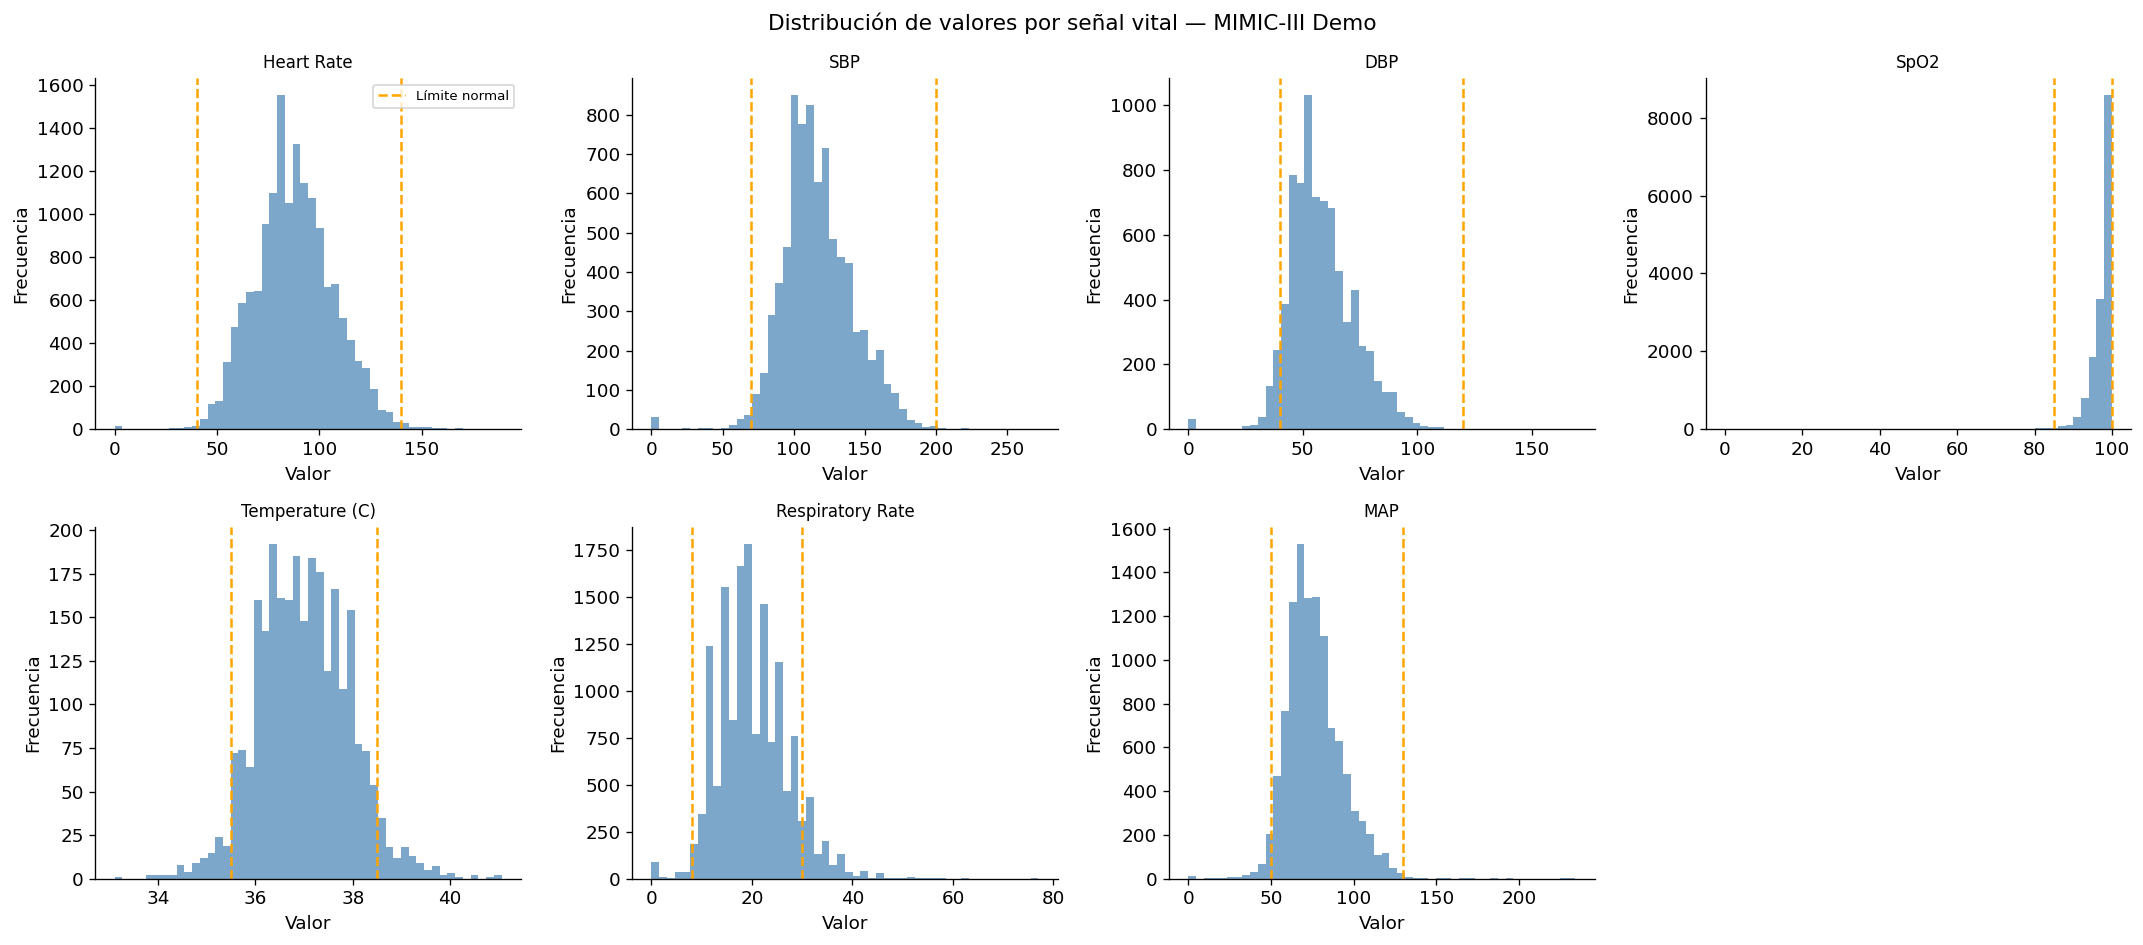

In [9]:
# ============================================================
# BLOQUE 6 — Validación de rangos fisiológicos
# ============================================================
# Por qué: CHARTEVENTS incluye errores de registro y mediciones
# artefactuales. Los valores fuera del rango fisiológico hard-limit
# son errores de entrada, no anomalías clínicas reales, y deben
# excluirse del entrenamiento. Los valores borderline se conservan
# como posibles anomalías reales para el protocolo de evaluación.

RANGOS_HARD = {
    'Heart Rate':        (0, 300),
    'SBP':               (0, 300),
    'DBP':               (0, 200),
    'SpO2':              (0, 100),
    'Temperature (C)':   (20, 45),
    'Respiratory Rate':  (0, 80),
    'MAP':               (0, 250)
}

RANGOS_NORMAL = {
    'Heart Rate':        (40, 140),
    'SBP':               (70, 200),
    'DBP':               (40, 120),
    'SpO2':              (85, 100),
    'Temperature (C)':   (35.5, 38.5),
    'Respiratory Rate':  (8, 30),
    'MAP':               (50, 130)
}

resultados_rangos = []

for senal, (hard_min, hard_max) in RANGOS_HARD.items():
    norm_min, norm_max = RANGOS_NORMAL[senal]
    subset = chart_vitals[chart_vitals['senal'] == senal]['valuenum'].dropna()
    if len(subset) == 0:
        continue
    fuera_hard   = ((subset < hard_min) | (subset > hard_max)).sum()
    fuera_normal = ((subset < norm_min) | (subset > norm_max)).sum()
    fuera_normal_excl = fuera_normal - fuera_hard
    resultados_rangos.append({
        'Señal':                    senal,
        'Total registros':          len(subset),
        'Rango normal':             f"[{norm_min}, {norm_max}]",
        'Errores (hard-limit)':     int(fuera_hard),
        'Anomalías clínicas':       int(fuera_normal_excl),
        '% errores':                round(fuera_hard / len(subset) * 100, 2),
        '% anomalías':              round(fuera_normal_excl / len(subset) * 100, 2)
    })

df_rangos = pd.DataFrame(resultados_rangos)
print("Validación de rangos fisiológicos:")
display(df_rangos)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for idx, (senal, (hard_min, hard_max)) in enumerate(RANGOS_HARD.items()):
    norm_min, norm_max = RANGOS_NORMAL[senal]
    subset = chart_vitals[
        (chart_vitals['senal'] == senal) &
        (chart_vitals['valuenum'] >= hard_min) &
        (chart_vitals['valuenum'] <= hard_max)
    ]['valuenum'].dropna()

    if len(subset) == 0:
        axes[idx].set_visible(False)
        continue

    axes[idx].hist(subset, bins=50, color='steelblue', alpha=0.7, edgecolor='none')
    axes[idx].axvline(norm_min, color='orange', linestyle='--', linewidth=1.5, label='Límite normal')
    axes[idx].axvline(norm_max, color='orange', linestyle='--', linewidth=1.5)
    axes[idx].set_title(senal, fontsize=10)
    axes[idx].set_xlabel('Valor')
    axes[idx].set_ylabel('Frecuencia')
    if idx == 0:
        axes[idx].legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Distribución de valores por señal vital — MIMIC-III Demo', fontsize=13)
plt.tight_layout()
plt.savefig('bloque6_distribuciones_senales.png', bbox_inches='tight')
plt.show()

---
## BLOQUE 7 — Análisis de tamaño de ventana temporal
Se determina el tamaño de ventana óptimo para el modelo considerando
la duración media de las estancias en UCI y la frecuencia de muestreo.

Columnas ICUSTAYS: ['row_id', 'subject_id', 'hadm_id', 'icustay_id', 'dbsource', 'first_careunit', 'last_careunit', 'first_wardid', 'last_wardid', 'intime', 'outtime', 'los']

Estadísticas de duración de estancias en UCI:
count    136.0
mean     106.9
std      148.7
min        2.5
25%       29.6
50%       50.7
75%      103.9
max      849.8
Name: duracion_horas, dtype: float64

Análisis de viabilidad de ventana (señales candidatas: 6)
Ventana (h)     Tensor shape         RAM float32 (KB)     RAM INT8 (KB)   Viable ESP8266?
-------------------------------------------------------------------------------------
8               (8 × 6)              0.19                 0.05            ✅ Sí
12              (12 × 6)             0.28                 0.07            ✅ Sí
16              (16 × 6)             0.38                 0.09            ✅ Sí
24              (24 × 6)             0.56                 0.14            ✅ Sí
48              (48 × 6)             1.12                 0.28        

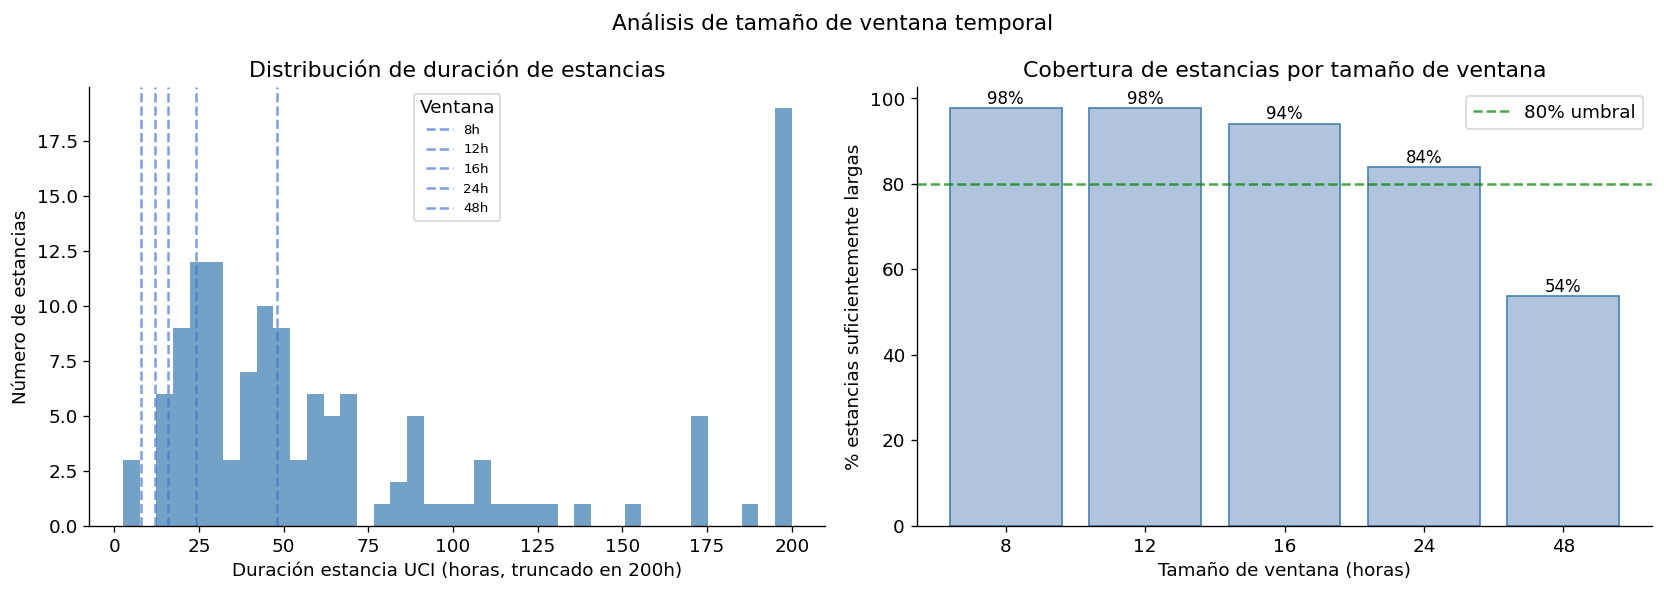


Ventana máxima con >= 80% de estancias cubiertas: 24 horas


In [10]:
# ============================================================
# BLOQUE 7 — Análisis de tamaño de ventana temporal
# ============================================================
# Por qué: el tamaño de ventana (W) determina directamente:
#   1. La cantidad de muestras disponibles para entrenamiento
#   2. El tamaño del tensor de entrada al modelo (W × n_señales)
#   3. La RAM necesaria en el ESP8266 (W × n_señales × 4 bytes en float32,
#      × 1 byte en INT8 tras cuantización)
# Restricción hardware: W × n_señales × 1 byte << 60 KB disponibles

ICUSTAYS_PATH = os.path.join(BASE_PATH, 'ICUSTAYS.csv')

# Detectar nombres de columna reales
cols_icu = pd.read_csv(ICUSTAYS_PATH, nrows=0).columns.tolist()
print("Columnas ICUSTAYS:", cols_icu)

icustays = pd.read_csv(ICUSTAYS_PATH)

# Normalizar columnas a minúsculas por si acaso
icustays.columns = icustays.columns.str.lower()

icustays['intime']  = pd.to_datetime(icustays['intime'])
icustays['outtime'] = pd.to_datetime(icustays['outtime'])
icustays['duracion_horas'] = (
    (icustays['outtime'] - icustays['intime']).dt.total_seconds() / 3600
)

print("\nEstadísticas de duración de estancias en UCI:")
print(icustays['duracion_horas'].describe().round(1))

POSIBLES_VENTANAS       = [8, 12, 16, 24, 48]
N_SENALES_CANDIDATO     = len(SENALES_VALIDAS) if SENALES_VALIDAS else 5

print(f"\nAnálisis de viabilidad de ventana (señales candidatas: {N_SENALES_CANDIDATO})")
print(f"{'Ventana (h)':<15} {'Tensor shape':<20} {'RAM float32 (KB)':<20} {'RAM INT8 (KB)':<15} {'Viable ESP8266?'}")
print("-" * 85)

for W in POSIBLES_VENTANAS:
    shape    = f"({W} × {N_SENALES_CANDIDATO})"
    ram_f32  = W * N_SENALES_CANDIDATO * 4 / 1024
    ram_int8 = W * N_SENALES_CANDIDATO * 1 / 1024
    viable   = "✅ Sí" if ram_int8 < 60 else "❌ No"
    print(f"{W:<15} {shape:<20} {ram_f32:<20.2f} {ram_int8:<15.2f} {viable}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    icustays['duracion_horas'].clip(upper=200),
    bins=40, color='steelblue', alpha=0.75, edgecolor='none'
)
for W in POSIBLES_VENTANAS:
    axes[0].axvline(W, linestyle='--', alpha=0.7, label=f'{W}h')
axes[0].set_xlabel('Duración estancia UCI (horas, truncado en 200h)')
axes[0].set_ylabel('Número de estancias')
axes[0].set_title('Distribución de duración de estancias')
axes[0].legend(fontsize=8, title='Ventana')

pcts = [(icustays['duracion_horas'] >= W).mean() * 100 for W in POSIBLES_VENTANAS]
bars = axes[1].bar([str(W) for W in POSIBLES_VENTANAS], pcts,
                   color='lightsteelblue', edgecolor='steelblue')
axes[1].axhline(80, color='green', linestyle='--', alpha=0.7, label='80% umbral')
axes[1].set_xlabel('Tamaño de ventana (horas)')
axes[1].set_ylabel('% estancias suficientemente largas')
axes[1].set_title('Cobertura de estancias por tamaño de ventana')
axes[1].legend()
for bar, pct in zip(bars, pcts):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 1, f'{pct:.0f}%', ha='center', fontsize=10)

plt.suptitle('Análisis de tamaño de ventana temporal', fontsize=13)
plt.tight_layout()
plt.savefig('bloque7_ventanas_temporales.png', bbox_inches='tight')
plt.show()

W_OPTIMO = None
for W in POSIBLES_VENTANAS:
    pct = (icustays['duracion_horas'] >= W).mean() * 100
    if pct >= 80:
        W_OPTIMO = W

print(f"\nVentana máxima con >= 80% de estancias cubiertas: {W_OPTIMO} horas")

---
## BLOQUE 8 — Síntesis y decisión de arquitectura
Integra los resultados de todos los bloques anteriores y produce
la decisión fundamentada sobre la arquitectura del modelo base.
**Este bloque es el output principal del EDA para el TFM.**

In [11]:
# ============================================================
# BLOQUE 8 — Síntesis del análisis exploratorio
# ============================================================
# Por qué: tras el EDA es necesario consolidar los hallazgos en
# decisiones técnicas documentadas sobre señales y preprocesamiento.
# La decisión de arquitectura se pospone al Bloque 9, donde se
# justifica con datos empíricos en lugar de argumentos teóricos.

import json

print("=" * 70)
print("SÍNTESIS DEL ANÁLISIS EXPLORATORIO — MIMIC-III Demo v1.4")
print("TFM: Optimización de modelos de IA mediante técnicas de Edge AI")
print("=" * 70)

# ── 1. SEÑALES DISPONIBLES ───────────────────────────────────
print("\n1. SEÑALES DISPONIBLES")
print("-" * 50)
for senal in SENALES.keys():
    fila = df_disponibilidad[df_disponibilidad['Señal'] == senal]
    if len(fila) == 0:
        continue
    cob = fila['Cobertura (%)'].values[0]
    estado = "✅ INCLUIDA" if cob >= 50 else "⚠️  BAJA COBERTURA (<50%) — EXCLUIDA"
    print(f"  {senal:<22} cobertura={cob:>5.1f}%  {estado}")

SENALES_FINALES = [
    s for s in SENALES.keys()
    if df_disponibilidad[
        df_disponibilidad['Señal'] == s
    ]['Cobertura (%)'].values[0] >= 50
]
N_SENALES = len(SENALES_FINALES)
print(f"\n  Señales seleccionadas ({N_SENALES}): {SENALES_FINALES}")
print(f"  Criterio de exclusión: cobertura < 50% de pacientes")
print(f"  Señal excluida: Temperature (C) — cobertura 49.5%")

# ── 2. PREPROCESAMIENTO DEFINIDO ─────────────────────────────
print("\n2. PREPROCESAMIENTO DEFINIDO")
print("-" * 50)
RESOLUCION   = '1h'
GAP_MAX      = 4
VENTANA      = W_OPTIMO if W_OPTIMO else 24
SOLAPAMIENTO = VENTANA // 2
print(f"  Resolución temporal:   {RESOLUCION} (remuestreo por mediana)")
print(f"  Imputación:            Forward-fill hasta {GAP_MAX}h; drop si gap mayor")
print(f"  Normalización:         MinMax [0, 1] por señal (fit solo en train)")
print(f"  Tamaño de ventana:     {VENTANA} pasos ({VENTANA}h)")
print(f"  Solapamiento:          {SOLAPAMIENTO} pasos (stride 50%)")
print(f"  Justificación ventana: {VENTANA}h cubre >= 80% de estancias UCI del demo")

# ── 3. RESTRICCIONES HARDWARE (ESP8266) ──────────────────────
print("\n3. RESTRICCIONES HARDWARE (ESP8266)")
print("-" * 50)
print(f"  CPU:               Xtensa LX106 @ 80 MHz, sin FPU")
print(f"  RAM disponible:    ~60 KB (tensor arena + pesos del modelo)")
print(f"  Latencia máx.:     500 ms por ventana de inferencia")
print(f"  Degradación F1:    ≤ 10% respecto al modelo base")
print(f"  Framework:         TensorFlow Lite for Microcontrollers (TFLM)")
print(f"  Cuantización:      INT8 obligatoria (sin FPU → float32 inviable)")

# Tamaño del tensor de entrada
tensor_bytes = VENTANA * N_SENALES * 1  # INT8: 1 byte/elemento
print(f"\n  Tensor entrada INT8:   {VENTANA} × {N_SENALES} = {tensor_bytes} bytes = {tensor_bytes/1024:.2f} KB")
print(f"  → El tensor de entrada es viable en cualquier arquitectura.")
print(f"  → El factor limitante es el tamaño de los PESOS del modelo.")

# ── 4. ARQUITECTURAS CANDIDATAS ──────────────────────────────
print("\n4. ARQUITECTURAS CANDIDATAS")
print("-" * 50)
print("  Se evaluarán empíricamente en el Bloque 9:")
print()
print("  A) Conv-AE (Conv1D Autoencoder)")
print("     Ventajas teóricas: captura patrones locales, compatible TFLM,")
print("     pesos compactos, sin estado recurrente.")
print()
print("  B) LSTM-AE (LSTM Autoencoder)")
print("     Ventajas teóricas: captura dependencias temporales largas.")
print("     Riesgo: pesos LSTM ~4× mayores, posible incompatibilidad RAM.")
print()
print("  C) Híbrido Conv+LSTM Autoencoder")
print("     Ventajas teóricas: combina patrones locales y temporales.")
print("     Riesgo: mayor complejidad, mayor RAM, mayor latencia.")
print()
print("  ⚠️  La selección final se realiza en el Bloque 9 con datos empíricos.")
print("  No se asume ninguna arquitectura como válida antes de la medición.")

# ── 5. ESTIMACIÓN DE MUESTRAS ────────────────────────────────
print("\n5. ESTIMACIÓN DE MUESTRAS DE ENTRENAMIENTO")
print("-" * 50)
n_estancias_validas   = (icustays['duracion_horas'] >= VENTANA).sum()
horas_mediana         = icustays['duracion_horas'].median()
ventanas_por_estancia = max(1, int((horas_mediana - VENTANA) / SOLAPAMIENTO))
total_ventanas        = n_estancias_validas * ventanas_por_estancia
print(f"  Estancias >= {VENTANA}h:              {n_estancias_validas}")
print(f"  Duración mediana estancia:         {horas_mediana:.1f}h")
print(f"  Ventanas aprox. por estancia:      ~{ventanas_por_estancia}")
print(f"  Total ventanas estimadas:          ~{total_ventanas}")
print(f"  Split train/val/test:              0.70 / 0.15 / 0.15")
print(f"  Ventanas entrenamiento aprox.:     ~{int(total_ventanas * 0.70)}")
print()
print(f"  Nota: dataset demo (100 pacientes) → muestra reducida.")
print(f"  Suficiente para establecer métricas baseline comparables.")
print(f"  No se busca generalización clínica sino comparativa de técnicas.")

# ── 6. GUARDAR CONFIG ────────────────────────────────────────
CONFIG_EDA = {
    'senales_entrada': SENALES_FINALES,
    'n_senales':       N_SENALES,
    'ventana_horas':   VENTANA,
    'solapamiento':    SOLAPAMIENTO,
    'resolucion':      RESOLUCION,
    'gap_max_horas':   GAP_MAX,
    'seed':            SEED,
    'arquitectura':    'PENDIENTE — ver Bloque 9'
}

with open('/kaggle/working/config_modelo_base.json', 'w', encoding='utf-8') as f:
    json.dump(CONFIG_EDA, f, ensure_ascii=False, indent=2)

print("\n" + "=" * 70)
print("FIN DEL ANÁLISIS EXPLORATORIO")
print("Siguiente paso: Bloque 9 — Comparativa empírica de arquitecturas")
print("=" * 70)
print("\nConfiguración parcial guardada en: /kaggle/working/config_modelo_base.json")
print("(Se actualizará con la arquitectura seleccionada tras el Bloque 9)")

SÍNTESIS DEL ANÁLISIS EXPLORATORIO — MIMIC-III Demo v1.4
TFM: Optimización de modelos de IA mediante técnicas de Edge AI

1. SEÑALES DISPONIBLES
--------------------------------------------------
  Heart Rate             cobertura= 99.0%  ✅ INCLUIDA
  SBP                    cobertura= 50.5%  ✅ INCLUIDA
  DBP                    cobertura= 50.5%  ✅ INCLUIDA
  SpO2                   cobertura= 99.0%  ✅ INCLUIDA
  Temperature (C)        cobertura= 49.5%  ⚠️  BAJA COBERTURA (<50%) — EXCLUIDA
  Respiratory Rate       cobertura= 99.0%  ✅ INCLUIDA
  MAP                    cobertura= 69.7%  ✅ INCLUIDA

  Señales seleccionadas (6): ['Heart Rate', 'SBP', 'DBP', 'SpO2', 'Respiratory Rate', 'MAP']
  Criterio de exclusión: cobertura < 50% de pacientes
  Señal excluida: Temperature (C) — cobertura 49.5%

2. PREPROCESAMIENTO DEFINIDO
--------------------------------------------------
  Resolución temporal:   1h (remuestreo por mediana)
  Imputación:            Forward-fill hasta 4h; drop si gap mayor


In [12]:
# ============================================================
# E1 — Configuración del entorno de entrenamiento
# ============================================================
# Por qué: se importan las librerías de entrenamiento y se carga
# la configuración producida por el B8 del EDA. De esta forma
# el entrenamiento es completamente reproducible y coherente
# con las decisiones tomadas durante la exploración.

import os, time, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score
)

warnings.filterwarnings('ignore')

# -- Semilla global (debe coincidir con el EDA) --
SEED = 42
os.environ['PYTHONHASHSEED']    = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
import random; random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow: {tf.__version__}")
print(f"SEED = {SEED}")

# -- Cargar config del EDA --
CONFIG_PATH = '/kaggle/working/config_modelo_base.json'
with open(CONFIG_PATH, 'r', encoding='utf-8') as f:
    config_eda = json.load(f)

# Parámetros del EDA
SENALES_FINALES = config_eda['senales_entrada']
N_SENALES       = config_eda['n_senales']
VENTANA         = config_eda['ventana_horas']
SOLAPAMIENTO    = config_eda['solapamiento']
RESOLUCION      = config_eda['resolucion']
GAP_MAX         = config_eda['gap_max_horas']

# Parámetros de entrenamiento
BATCH_SIZE  = 32
EPOCHS      = 100
LR          = 1e-3
PATIENCE    = 15
UMBRAL_PCT  = 95
SPLIT_TRAIN = 0.70
SPLIT_VAL   = 0.15
SPLIT_TEST  = 0.15

# ITEMIDs por señal (resultado EDA Bloque 3)
ITEMIDS = {
    'Heart Rate':       [211, 220045],
    'SBP':              [51, 220050, 225309],
    'DBP':              [8368, 220051, 225310],
    'SpO2':             [646, 220277],
    'Respiratory Rate': [618, 220210],
    'MAP':              [52, 456, 220052, 225312]
}

# Hard-limits fisiológicos (resultado EDA Bloque 6)
RANGOS_HARD = {
    'Heart Rate':       (0, 300),
    'SBP':              (0, 300),
    'DBP':              (0, 200),
    'SpO2':             (0, 100),
    'Respiratory Rate': (0, 80),
    'MAP':              (0, 250)
}

# -- Ruta dataset --
# En notebook unificado BASE_PATH ya viene definido del EDA (B1).
# Solo redefinir si no existe.
if 'BASE_PATH' not in dir() or not os.path.exists(BASE_PATH):
    import glob
    posibles = glob.glob('/kaggle/input/*/CHARTEVENTS.csv')
    if posibles:
        BASE_PATH = os.path.dirname(posibles[0])
    else:
        # Detectar manualmente
        for carpeta in os.listdir('/kaggle/input'):
            ruta = f'/kaggle/input/{carpeta}'
            if os.path.isdir(ruta):
                BASE_PATH = ruta
                break

print(f"\nDataset: {BASE_PATH}")
print(f"Señales: {SENALES_FINALES}")
print(f"Ventana: {VENTANA}h | Stride: {SOLAPAMIENTO}h | Resolución: {RESOLUCION}")
print(f"CHARTEVENTS existe: {os.path.exists(os.path.join(BASE_PATH, 'CHARTEVENTS.csv'))}")

TensorFlow: 2.20.0
SEED = 42

Dataset: /kaggle/input/datasets/montassarba/mimic-iii-clinical-database-demo-1-4/mimic-iii-clinical-database-demo-1.4
Señales: ['Heart Rate', 'SBP', 'DBP', 'SpO2', 'Respiratory Rate', 'MAP']
Ventana: 24h | Stride: 12h | Resolución: 1h
CHARTEVENTS existe: True


In [13]:
# ============================================================
# E2 — Pipeline de preprocesamiento
# ============================================================
# Por qué: implementa exactamente el protocolo definido en el
# B8 del EDA:
#   1. Cargar CHARTEVENTS filtrando solo señales objetivo
#   2. Eliminar errores de registro (hard-limit)
#   3. Remuestrear a grilla horaria (mediana)
#   4. Forward-fill hasta GAP_MAX horas
#   5. Construir DataFrame multivariante por paciente

print("Cargando CHARTEVENTS...")
chart = pd.read_csv(
    os.path.join(BASE_PATH, 'CHARTEVENTS.csv'),
    usecols=['subject_id', 'icustay_id', 'itemid', 'charttime', 'valuenum'],
    dtype={
        'subject_id': 'int32',
        'icustay_id': 'float32',
        'itemid':     'int32',
        'valuenum':   'float32'
    },
    parse_dates=['charttime'],
    low_memory=False
)

# Mapear itemid → señal
itemid_to_senal = {
    iid: senal
    for senal, ids in ITEMIDS.items()
    for iid in ids
}
todos_ids = list(itemid_to_senal.keys())

# Filtrar señales objetivo con valor numérico
chart = chart[
    chart['itemid'].isin(todos_ids) &
    chart['valuenum'].notna()
].copy()
chart['senal'] = chart['itemid'].map(itemid_to_senal)

# Eliminar errores hard-limit
mask_valido = pd.Series(True, index=chart.index)
for senal, (lo, hi) in RANGOS_HARD.items():
    m = chart['senal'] == senal
    mask_valido &= ~(m & ((chart['valuenum'] < lo) | (chart['valuenum'] > hi)))
chart = chart[mask_valido].copy()

print(f"Registros tras filtrado: {len(chart):,}")
print(f"Pacientes: {chart['subject_id'].nunique()}")

# Construir series multivariantes por paciente
print("Construyendo series multivariantes...")
series_pacientes = {}

for subject_id, grupo in chart.groupby('subject_id'):
    grupo = grupo.set_index('charttime').sort_index()
    frames = []
    for senal in SENALES_FINALES:
        subset = grupo[grupo['senal'] == senal]['valuenum']
        if len(subset) < 2:
            frames.append(pd.Series(name=senal, dtype='float32'))
            continue
        serie = subset.resample(RESOLUCION).median()
        serie = serie.ffill(limit=GAP_MAX)
        frames.append(serie.rename(senal))

    if not frames or all(f.empty for f in frames):
        continue

    df_pac = pd.concat(frames, axis=1).dropna()
    if len(df_pac) >= VENTANA:
        series_pacientes[subject_id] = df_pac

print(f"Pacientes con series válidas (>= {VENTANA}h): {len(series_pacientes)}")
print(f"\nEjemplo — paciente {list(series_pacientes.keys())[0]}:")
display(list(series_pacientes.values())[0].head(3))

Cargando CHARTEVENTS...
Registros tras filtrado: 72,466
Pacientes: 98
Construyendo series multivariantes...
Pacientes con series válidas (>= 24h): 32

Ejemplo — paciente 10013:


,Heart Rate,SBP,DBP,SpO2,Respiratory Rate,MAP
charttime,,,,,,
2125-10-05 00:00:00,96.0,128.0,49.0,93.0,26.0,54.666698
2125-10-05 01:00:00,96.0,132.0,49.0,83.0,18.0,56.333302
2125-10-05 02:00:00,103.0,132.0,49.0,92.0,22.0,60.333302


In [14]:
# ============================================================
# E3 — Construcción del dataset de ventanas
# ============================================================
# Por qué: el Conv-AE opera sobre ventanas de tamaño fijo.
# El split se hace por paciente para evitar data leakage temporal
# (ventanas del mismo paciente no pueden estar en train y test).
# La normalización MinMax se ajusta solo sobre train.

def extraer_ventanas(serie_df, ventana, stride):
    """Extrae ventanas deslizantes de un DataFrame multivariante."""
    valores = serie_df.values.astype('float32')
    return np.array([
        valores[i:i + ventana]
        for i in range(0, len(valores) - ventana + 1, stride)
    ])


# Split por paciente
pacientes = list(series_pacientes.keys())
np.random.shuffle(pacientes)

n_train = int(len(pacientes) * SPLIT_TRAIN)
n_val   = int(len(pacientes) * SPLIT_VAL)

pac_train = pacientes[:n_train]
pac_val   = pacientes[n_train:n_train + n_val]
pac_test  = pacientes[n_train + n_val:]

print(f"Pacientes — train: {len(pac_train)}, val: {len(pac_val)}, test: {len(pac_test)}")

# Normalización MinMax: fit solo en train
datos_train_raw = np.vstack([
    series_pacientes[p].values for p in pac_train
])
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(datos_train_raw)

print(f"Scaler ajustado — mín: {scaler.data_min_.round(2)}")
print(f"                  máx: {scaler.data_max_.round(2)}")


def construir_split(lista_pacs):
    """Normaliza y extrae ventanas para una lista de pacientes."""
    ventanas = []
    for p in lista_pacs:
        serie = series_pacientes[p]
        serie_norm = pd.DataFrame(
            scaler.transform(serie.values),
            index=serie.index,
            columns=serie.columns
        )
        vents = extraer_ventanas(serie_norm, VENTANA, SOLAPAMIENTO)
        if len(vents) > 0:
            ventanas.append(vents)
    return np.vstack(ventanas) if ventanas else np.empty((0, VENTANA, N_SENALES))


X_train = construir_split(pac_train)
X_val   = construir_split(pac_val)
X_test  = construir_split(pac_test)

# Si X_test vacío por dataset pequeño, usar X_val como proxy
if len(X_test) == 0:
    print("⚠️  X_test vacío (dataset demo pequeño). Usando X_val como test.")
    X_test = X_val.copy()

print(f"\nFormas del dataset:")
print(f"  X_train: {X_train.shape}  ({X_train.nbytes / 1024:.1f} KB)")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"\nRango valores — min: {X_train.min():.4f}, max: {X_train.max():.4f}")

Pacientes — train: 22, val: 4, test: 6
Scaler ajustado — mín: [23.   0.   0.   0.   0.  23.5]
                  máx: [155. 216. 169. 100.  58. 234.]

Formas del dataset:
  X_train: (369, 24, 6)  (207.6 KB)
  X_val:   (51, 24, 6)
  X_test:  (80, 24, 6)

Rango valores — min: 0.0000, max: 1.0000


## BLOQUE 9 — Comparativa empírica de arquitecturas
Justificación basada en datos de la selección del Conv-AE frente a
LSTM-AE e Híbrido Conv+LSTM bajo las restricciones del ESP8266.

**Condiciones de comparación (controladas):**
- Mismo dataset: `X_train`, `X_val` del pipeline anterior
- Mismo input shape: `(24, 6)`
- Mismas épocas fijas: `EPOCAS_COMP = 30` (comparación, no convergencia)
- Mismo batch size, lr y seed
- Mismo protocolo de medición de latencia (100 repeticiones)

**Métricas registradas por arquitectura:**
1. Parámetros totales
2. Compatibilidad con TFLM (conversión TFLite estándar)
3. Tamaño TFLite float32 (KB)
4. Tamaño estimado INT8 (KB)
5. RAM estimada ESP8266 (KB)
6. Val loss tras 30 épocas
7. Latencia media inferencia Python (ms/ventana)


  Arquitectura: Conv-AE
  Parámetros: 5,102


2026-07-12 17:07:20.650363: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2026-07-12 17:07:20.858026: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


  Val loss: 0.010383  (30 épocas, 7.7s)
INFO:tensorflow:Assets written to: /tmp/tmpnp8ph705/assets


INFO:tensorflow:Assets written to: /tmp/tmpnp8ph705/assets


Saved artifact at '/tmp/tmpnp8ph705'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 24, 6), dtype=tf.float32, name='input')
Output Type:
  TensorSpec(shape=(None, 24, 6), dtype=tf.float32, name=None)
Captures:
  138620531959824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138620531960400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138620531961744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138620531957712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138620531959632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138620531962704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138620531962128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138620531961360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138620531963664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138620531963856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138620531960976: Tensor

...

W0000 00:00:1783876101.828353      58 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1783876101.828385      58 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-07-12 17:08:22.024608: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute Truncate which is not in the op definition: Op<name=Identity; signature=input:T -> output:T; attr=T:type> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node unnamed}}
loc(callsite(fused["TensorListReserve:", "Hibrido_AE_1/lstm_1/TensorArrayV2_1@__inference_function_46473"] at callsite(fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_46532"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"]))): error: 'tf.TensorListReserve' op requires element_shape to be static during TF Lite transformation pass
loc(callsite(fused["TensorListReserve:", "Hibrido_AE_1/l

  ❌ Conversión TFLite FALLIDA
  Causa: <unknown>:0: error: loc(callsite(fused["TensorListReserve:", "Hibrido_AE_1/lstm_1/TensorArrayV2_1@__inference_function_46473"] at callsite(fused["Stat...
  → Arquitectura NO desplegable en ESP8266 via TFLM estándar


2026-07-12 17:08:27.052850: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


  Latencia:       79.64 ms (media)  83.64 ms (p95)

TABLA COMPARATIVA DE ARQUITECTURAS


,Parámetros,Compatible TFLM,TFLite f32 (KB),INT8 est. (KB),RAM ESP8266 (KB),Val loss (30ep),Latencia ms,Latencia p95 ms,Viable RAM,Viable latencia
Arquitectura,,,,,,,,,,
Conv-AE,5102,True,34.23,8.56,17.12,0.010383,77.31,81.85,True,True
LSTM-AE,16710,False,N/A,N/A,N/A,0.010263,81.45,86.44,False,True
Hibrido-AE,7622,False,N/A,N/A,N/A,0.004198,79.64,83.64,False,True


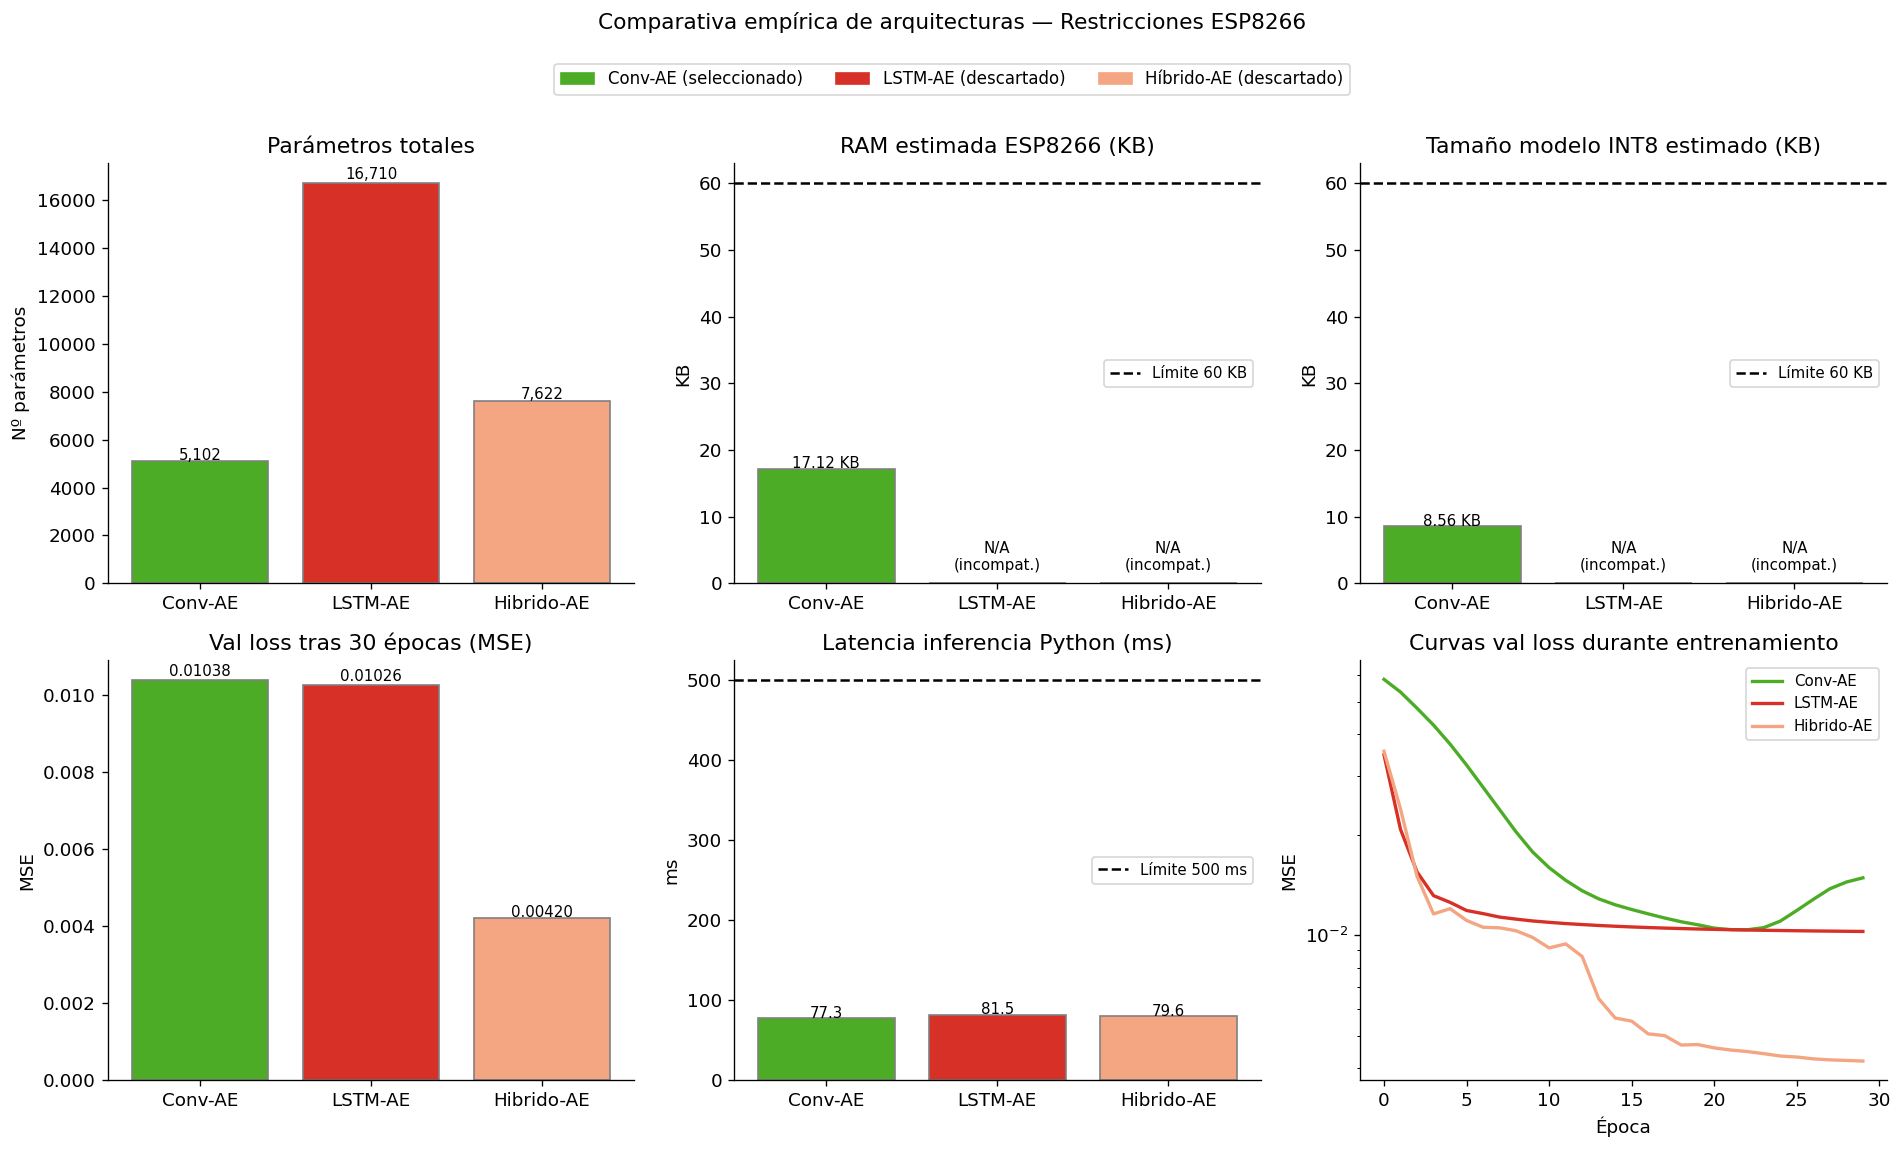


VEREDICTO — Selección de arquitectura
  Conv-AE         ✅ VIABLE
    → cumple todas las restricciones del ESP8266
  LSTM-AE         ❌ DESCARTADA
    → incompatible con TFLM (conversión TFLite pudo tener éxito, pero usa operadores no soportados en microcontroladores)
  Hibrido-AE      ❌ DESCARTADA
    → incompatible con TFLM (conversión TFLite pudo tener éxito, pero usa operadores no soportados en microcontroladores)

Arquitectura seleccionada para OE2: Conv-AE (con decoder Conv1DTranspose)
Justificación empírica:
  - Única arquitectura verificada como compatible con TFLM real
    (no solo con conversión TFLite)
  - Única arquitectura desplegable en ESP8266 vía TFLM
  - RAM estimada dentro del límite de 60 KB
  - Latencia dentro del límite de 500 ms

Archivos guardados:
  /kaggle/working/B9_comparativa_arquitecturas.json
  /kaggle/working/B9_comparativa_arquitecturas.png


In [15]:
# ============================================================
# BLOQUE 9 — Comparativa empírica de arquitecturas
# ============================================================
# Por qué: la selección del Conv-AE no puede justificarse solo
# con argumentos teóricos. Este bloque entrena las 3 arquitecturas
# candidatas bajo condiciones idénticas y mide empíricamente
# su viabilidad bajo las restricciones del ESP8266.
#
# CORRECCIÓN (revisión julio 2026): la verificación original
# comprobaba únicamente que converter.convert() no lanzase
# excepción, lo cual valida compatibilidad con TFLite completo
# (móvil/servidor), NO con TFLM (TensorFlow Lite for
# Microcontrollers). TFLM soporta un subconjunto de 115
# operadores (lista oficial consultada en
# tensorflow/tflite-micro, julio 2026) que NO incluye TILE,
# operador generado por UpSampling1D/tf.repeat. Esta limitación
# se descubrió empíricamente al desplegar en hardware real
# (ver Anexo D), tras lo cual se corrigió este bloque para
# verificar compatibilidad TFLM real, no solo conversión TFLite.

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, Conv1DTranspose, BatchNormalization,
    LSTM, RepeatVector, TimeDistributed, Dense
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# -- Parámetros de comparación --
EPOCAS_COMP = 30     # fijas para todos — no es convergencia, es comparación
BATCH_COMP  = 32
LR_COMP     = 1e-3
N_REP_LAT   = 100    # repeticiones para medir latencia
RAM_LIMITE  = 60     # KB — restricción ESP8266
LAT_LIMITE  = 500    # ms — restricción ESP8266

tf.random.set_seed(SEED)


# ============================================================
# Verificación de compatibilidad TFLM real
# ============================================================
# Lista de operadores soportados por TFLM (TensorFlow Lite for
# Microcontrollers), extraída de tensorflow/tflite-micro
# (tensorflow/lite/micro/kernels/micro_ops.h, rama main,
# consultada en julio 2026). Notablemente NO incluye TILE.

OPERADORES_TFLM_SOPORTADOS = {
    'ABS', 'ADD', 'ADD_N', 'ARG_MAX', 'ARG_MIN', 'ASSIGN_VARIABLE',
    'AVERAGE_POOL_2D', 'BATCH_MATMUL', 'BATCH_TO_SPACE_ND', 'BROADCAST_ARGS',
    'BROADCAST_TO', 'CALL_ONCE', 'CAST', 'CEIL', 'CIRCULAR_BUFFER',
    'CONCATENATION', 'CONV_2D', 'COS', 'CUMSUM', 'DECODE', 'DELAY',
    'DEPTHWISE_CONV_2D', 'DEPTH_TO_SPACE', 'DEQUANTIZE', 'DIV',
    'DYNAMIC_UPDATE_SLICE', 'ELU', 'EMBEDDING_LOOKUP', 'ENERGY', 'EQUAL',
    'ETHOSU', 'EXP', 'EXPAND_DIMS', 'FFT_AUTO_SCALE', 'FILL', 'FILTER_BANK',
    'FILTER_BANK_LOG', 'FILTER_BANK_SPECTRAL_SUBTRACTION',
    'FILTER_BANK_SQUARE_ROOT', 'FLOOR', 'FLOOR_DIV', 'FLOOR_MOD', 'FRAMER',
    'FULLY_CONNECTED', 'GATHER', 'GATHER_ND', 'GREATER', 'GREATER_EQUAL',
    'HARD_SWISH', 'IF', 'L2_NORMALIZATION', 'L2_POOL_2D', 'LEAKY_RELU',
    'LESS', 'LESS_EQUAL', 'LOG', 'LOGICAL_AND', 'LOGICAL_NOT', 'LOGICAL_OR',
    'LOGISTIC', 'LOG_SOFTMAX', 'MAXIMUM', 'MAX_POOL_2D', 'MEAN', 'MINIMUM',
    'MIRROR_PAD', 'MUL', 'NEG', 'NOT_EQUAL', 'OVERLAP_ADD', 'PACK', 'PAD',
    'PADV2', 'PCAN', 'PRELU', 'QUANTIZE', 'READ_VARIABLE', 'REDUCE_ALL',
    'REDUCE_MAX', 'REDUCE_MIN', 'RELU', 'RELU6', 'RESHAPE', 'RESIZE_BILINEAR',
    'RESIZE_NEAREST_NEIGHBOR', 'REVERSE_V2', 'ROUND', 'RSQRT', 'SELECT_V2',
    'SHAPE', 'SIN', 'SLICE', 'SOFTMAX', 'SPACE_TO_BATCH_ND', 'SPACE_TO_DEPTH',
    'SPLIT', 'SPLIT_V', 'SQRT', 'SQUARE', 'SQUARED_DIFFERENCE', 'SQUEEZE',
    'STACKER', 'STRIDED_SLICE', 'SUB', 'SUM', 'SVDF', 'TANH', 'TRANSPOSE',
    'TRANSPOSE_CONV', 'UNIDIRECTIONAL_SEQUENCE_LSTM', 'UNPACK', 'VAR_HANDLE',
    'WHILE', 'WINDOW', 'ZEROS_LIKE'
}


def verificar_compatibilidad_tflm(tflite_bytes):
    """
    Verifica si un modelo .tflite ya convertido usa únicamente
    operadores soportados por TFLM, inspeccionando el flatbuffer
    sin delegates (BUILTIN_WITHOUT_DEFAULT_DELEGATES), que es como
    lo verá el intérprete TFLM real en el microcontrolador.

    Returns:
        (compatible: bool, ops_usados: set, ops_no_soportados: set)
    """
    interpreter = tf.lite.Interpreter(
        model_content=tflite_bytes,
        experimental_op_resolver_type=(
            tf.lite.experimental.OpResolverType.BUILTIN_WITHOUT_DEFAULT_DELEGATES
        )
    )
    interpreter.allocate_tensors()
    ops_usados = set()
    for op_details in interpreter._get_ops_details():
        ops_usados.add(op_details['op_name'])
    ops_no_soportados = ops_usados - OPERADORES_TFLM_SOPORTADOS
    compatible = len(ops_no_soportados) == 0
    return compatible, ops_usados, ops_no_soportados


# ============================================================
# Definición de las 3 arquitecturas candidatas
# ============================================================

def construir_conv_ae_comp(ventana, n_senales, seed=42):
    """Conv1D Autoencoder — arquitectura candidata seleccionada.

    NOTA (corrección julio 2026): decoder reescrito con
    Conv1DTranspose en lugar de UpSampling1D + Conv1D. La versión
    original generaba el operador TILE al convertir a TFLite
    (vía UpSampling1D), operador no soportado por TFLM. Conv1DTranspose
    con strides=2 sustituye el patrón UpSampling1D(2)+Conv1D con una
    capa aprendida equivalente, generando TRANSPOSE_CONV (sí soportado).
    """
    tf.random.set_seed(seed)
    ini = tf.keras.initializers.GlorotUniform(seed=seed)
    inp = Input(shape=(ventana, n_senales), name='input')
    x = Conv1D(32, 3, activation='relu', padding='same',
               kernel_initializer=ini)(inp)
    x = BatchNormalization()(x)
    x = MaxPooling1D(2)(x)
    x = Conv1D(16, 3, activation='relu', padding='same',
               kernel_initializer=ini)(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(2)(x)
    x = Conv1D(8, 3, activation='relu', padding='same',
               kernel_initializer=ini)(x)
    x = Conv1DTranspose(16, kernel_size=3, strides=2, activation='relu',
                         padding='same', kernel_initializer=ini)(x)
    x = BatchNormalization()(x)
    x = Conv1DTranspose(32, kernel_size=3, strides=2, activation='relu',
                         padding='same', kernel_initializer=ini)(x)
    x = BatchNormalization()(x)
    out = Conv1D(n_senales, 1, activation='sigmoid',
                 kernel_initializer=ini)(x)
    m = Model(inp, out, name='Conv_AE')
    m.compile(optimizer=Adam(LR_COMP), loss='mse')
    return m


def construir_lstm_ae_comp(ventana, n_senales, seed=42):
    """LSTM Autoencoder — candidato con riesgo de incompatibilidad TFLM."""
    tf.random.set_seed(seed)
    ini = tf.keras.initializers.GlorotUniform(seed=seed)
    inp = Input(shape=(ventana, n_senales), name='input')
    x = LSTM(32, activation='tanh', return_sequences=True,
             kernel_initializer=ini)(inp)
    x = LSTM(16, activation='tanh', return_sequences=False,
             kernel_initializer=ini)(x)
    x = RepeatVector(ventana)(x)
    x = LSTM(16, activation='tanh', return_sequences=True,
             kernel_initializer=ini)(x)
    x = LSTM(32, activation='tanh', return_sequences=True,
             kernel_initializer=ini)(x)
    out = TimeDistributed(
        Dense(n_senales, activation='sigmoid', kernel_initializer=ini)
    )(x)
    m = Model(inp, out, name='LSTM_AE')
    m.compile(optimizer=Adam(LR_COMP), loss='mse')
    return m


def construir_hibrido_ae_comp(ventana, n_senales, seed=42):
    """Híbrido Conv+LSTM Autoencoder — candidato con riesgo de incompatibilidad TFLM."""
    tf.random.set_seed(seed)
    ini = tf.keras.initializers.GlorotUniform(seed=seed)
    inp = Input(shape=(ventana, n_senales), name='input')
    x = Conv1D(32, 3, activation='relu', padding='same',
               kernel_initializer=ini)(inp)
    x = MaxPooling1D(2)(x)
    x = LSTM(16, activation='tanh', return_sequences=False,
             kernel_initializer=ini)(x)
    x = RepeatVector(ventana)(x)
    x = LSTM(16, activation='tanh', return_sequences=True,
             kernel_initializer=ini)(x)
    x = Conv1D(32, 3, activation='relu', padding='same',
               kernel_initializer=ini)(x)
    out = Conv1D(n_senales, 1, activation='sigmoid',
                 kernel_initializer=ini)(x)
    m = Model(inp, out, name='Hibrido_AE')
    m.compile(optimizer=Adam(LR_COMP), loss='mse')
    return m


ARQUITECTURAS = {
    'Conv-AE':    construir_conv_ae_comp,
    'LSTM-AE':    construir_lstm_ae_comp,
    'Hibrido-AE': construir_hibrido_ae_comp
}


# ============================================================
# Entrenamiento y medición por arquitectura
# ============================================================

resultados  = []
historiales = {}

for nombre, fn_constructor in ARQUITECTURAS.items():
    print(f"\n{'='*55}")
    print(f"  Arquitectura: {nombre}")
    print(f"{'='*55}")

    tf.random.set_seed(SEED)
    modelo_comp = fn_constructor(VENTANA, N_SENALES, seed=SEED)
    n_params    = modelo_comp.count_params()
    print(f"  Parámetros: {n_params:,}")

    # -- Entrenamiento con épocas fijas --
    t0 = time.time()
    hist = modelo_comp.fit(
        X_train, X_train,
        validation_data=(X_val, X_val),
        epochs=EPOCAS_COMP,
        batch_size=BATCH_COMP,
        verbose=0,
        callbacks=[
            EarlyStopping(
                monitor='val_loss',
                patience=10,
                restore_best_weights=True,
                verbose=0
            )
        ]
    )
    t_train        = time.time() - t0
    val_loss_final = min(hist.history['val_loss'])
    historiales[nombre] = hist.history
    print(f"  Val loss: {val_loss_final:.6f}  "
          f"({len(hist.history['loss'])} épocas, {t_train:.1f}s)")

    # -- Conversión TFLite + verificación de compatibilidad TFLM real --
    # Por qué: LSTM usa TensorListReserve (no soportado en TFLM) y el
    # decoder original con UpSampling1D generaba TILE (tampoco soportado).
    # La conversión exitosa a .tflite NO garantiza ejecución en TFLM;
    # se verifica el conjunto real de operadores del flatbuffer.
    converter = tf.lite.TFLiteConverter.from_keras_model(modelo_comp)
    try:
        tflite_bytes = converter.convert()
        compatible_tflm, ops_usados, ops_no_soportados = (
            verificar_compatibilidad_tflm(tflite_bytes)
        )
        tam_f32_kb  = len(tflite_bytes) / 1024
        tam_int8_kb = tam_f32_kb / 4
        ram_est_kb  = tam_int8_kb * 2

        if compatible_tflm:
            print(f"  TFLite f32:     {tam_f32_kb:.2f} KB")
            print(f"  Estimado INT8:  {tam_int8_kb:.2f} KB")
            print(f"  RAM estimada:   {ram_est_kb:.2f} KB  "
                  f"{'✅' if ram_est_kb < RAM_LIMITE else '❌'} "
                  f"(límite {RAM_LIMITE} KB)")
            print(f"  ✅ Compatible con TFLM — operadores: {sorted(ops_usados)}")
        else:
            print(f"  ❌ Conversión TFLite exitosa PERO incompatible con TFLM")
            print(f"  Operadores no soportados por TFLM: {sorted(ops_no_soportados)}")
            print(f"  → Arquitectura NO ejecutable en ESP8266 pese a conversión OK")
            tam_f32_kb = tam_int8_kb = ram_est_kb = None
    except Exception as e:
        compatible_tflm = False
        tam_f32_kb = tam_int8_kb = ram_est_kb = None
        print(f"  ❌ Conversión TFLite FALLIDA")
        print(f"  Causa: {str(e)[:150]}...")
        print(f"  → Arquitectura NO desplegable en ESP8266 via TFLM estándar")

    # -- Latencia de inferencia (100 repeticiones, 1 ventana) --
    ventana_ref = X_val[:1]
    for _ in range(10):  # warm-up
        modelo_comp.predict(ventana_ref, verbose=0)
    tiempos_lat = []
    for _ in range(N_REP_LAT):
        t_i = time.perf_counter()
        modelo_comp.predict(ventana_ref, verbose=0)
        tiempos_lat.append((time.perf_counter() - t_i) * 1000)
    lat_media = np.mean(tiempos_lat)
    lat_p95   = np.percentile(tiempos_lat, 95)
    print(f"  Latencia:       {lat_media:.2f} ms (media)  "
          f"{lat_p95:.2f} ms (p95)")

    resultados.append({
        'Arquitectura':     nombre,
        'Parámetros':       n_params,
        'Compatible TFLM':  compatible_tflm,
        'TFLite f32 (KB)':  round(tam_f32_kb, 2) if compatible_tflm else 'N/A',
        'INT8 est. (KB)':   round(tam_int8_kb, 2) if compatible_tflm else 'N/A',
        'RAM ESP8266 (KB)': round(ram_est_kb, 2) if compatible_tflm else 'N/A',
        'Val loss (30ep)':  round(val_loss_final, 6),
        'Latencia ms':      round(lat_media, 2),
        'Latencia p95 ms':  round(lat_p95, 2),
        'Viable RAM':       compatible_tflm and ram_est_kb is not None and ram_est_kb < RAM_LIMITE,
        'Viable latencia':  lat_media < LAT_LIMITE
    })

    # Liberar memoria entre arquitecturas
    del modelo_comp
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)


# ============================================================
# Tabla comparativa
# ============================================================

df_comp = pd.DataFrame(resultados)

print("\n" + "=" * 70)
print("TABLA COMPARATIVA DE ARQUITECTURAS")
print("=" * 70)
display(df_comp.set_index('Arquitectura'))


# ============================================================
# Visualizaciones
# ============================================================

nombres = df_comp['Arquitectura'].tolist()
colores = ['#4dac26', '#d73027', '#f4a582']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

# 1. Parámetros totales
axes[0].bar(nombres, df_comp['Parámetros'], color=colores, edgecolor='gray')
axes[0].set_title('Parámetros totales')
axes[0].set_ylabel('Nº parámetros')
for i, v in enumerate(df_comp['Parámetros']):
    axes[0].text(i, v * 1.01, f'{v:,}', ha='center', fontsize=9)

# 2. RAM estimada ESP8266
ram_vals   = [float(r) if r != 'N/A' else 0 for r in df_comp['RAM ESP8266 (KB)']]
ram_labels = [f"{r} KB" if r != 'N/A' else 'N/A\n(incompat.)'
              for r in df_comp['RAM ESP8266 (KB)']]
axes[1].bar(nombres, ram_vals, color=colores, edgecolor='gray')
axes[1].axhline(RAM_LIMITE, color='black', linestyle='--',
                linewidth=1.5, label=f'Límite {RAM_LIMITE} KB')
axes[1].set_title('RAM estimada ESP8266 (KB)')
axes[1].set_ylabel('KB')
axes[1].legend(fontsize=9)
for i, (v, label) in enumerate(zip(ram_vals, ram_labels)):
    axes[1].text(i, max(v * 1.01, 2), label, ha='center', fontsize=9)

# 3. Tamaño INT8 estimado
int8_vals   = [float(r) if r != 'N/A' else 0 for r in df_comp['INT8 est. (KB)']]
int8_labels = [f"{r} KB" if r != 'N/A' else 'N/A\n(incompat.)'
               for r in df_comp['INT8 est. (KB)']]
axes[2].bar(nombres, int8_vals, color=colores, edgecolor='gray')
axes[2].axhline(RAM_LIMITE, color='black', linestyle='--',
                linewidth=1.5, label=f'Límite {RAM_LIMITE} KB')
axes[2].set_title('Tamaño modelo INT8 estimado (KB)')
axes[2].set_ylabel('KB')
axes[2].legend(fontsize=9)
for i, (v, label) in enumerate(zip(int8_vals, int8_labels)):
    axes[2].text(i, max(v * 1.01, 2), label, ha='center', fontsize=9)

# 4. Val loss
axes[3].bar(nombres, df_comp['Val loss (30ep)'], color=colores, edgecolor='gray')
axes[3].set_title(f'Val loss tras {EPOCAS_COMP} épocas (MSE)')
axes[3].set_ylabel('MSE')
for i, v in enumerate(df_comp['Val loss (30ep)']):
    axes[3].text(i, v * 1.01, f'{v:.5f}', ha='center', fontsize=9)

# 5. Latencia
axes[4].bar(nombres, df_comp['Latencia ms'], color=colores, edgecolor='gray')
axes[4].axhline(LAT_LIMITE, color='black', linestyle='--',
                linewidth=1.5, label=f'Límite {LAT_LIMITE} ms')
axes[4].set_title('Latencia inferencia Python (ms)')
axes[4].set_ylabel('ms')
axes[4].legend(fontsize=9)
for i, v in enumerate(df_comp['Latencia ms']):
    axes[4].text(i, v * 1.01, f'{v:.1f}', ha='center', fontsize=9)

# 6. Curvas val loss
for nombre, color in zip(nombres, colores):
    axes[5].plot(
        historiales[nombre]['val_loss'],
        label=nombre, color=color, linewidth=2
    )
axes[5].set_title('Curvas val loss durante entrenamiento')
axes[5].set_xlabel('Época')
axes[5].set_ylabel('MSE')
axes[5].legend(fontsize=9)
axes[5].set_yscale('log')

# Leyenda global
parche_verde   = mpatches.Patch(color='#4dac26', label='Conv-AE (seleccionado)')
parche_rojo    = mpatches.Patch(color='#d73027', label='LSTM-AE (descartado)')
parche_naranja = mpatches.Patch(color='#f4a582', label='Híbrido-AE (descartado)')
fig.legend(
    handles=[parche_verde, parche_rojo, parche_naranja],
    loc='upper center', ncol=3, fontsize=10,
    bbox_to_anchor=(0.5, 1.02)
)
plt.suptitle(
    'Comparativa empírica de arquitecturas — Restricciones ESP8266',
    fontsize=13, y=1.06
)
plt.tight_layout()
plt.savefig(
    '/kaggle/working/B9_comparativa_arquitecturas.png',
    bbox_inches='tight', dpi=150
)
plt.show()


# ============================================================
# Veredicto final
# ============================================================

print("\n" + "=" * 70)
print("VEREDICTO — Selección de arquitectura")
print("=" * 70)

for _, row in df_comp.iterrows():
    viable = row['Viable RAM'] and row['Viable latencia']
    estado = "✅ VIABLE" if viable else "❌ DESCARTADA"
    razones = []
    if not row['Compatible TFLM']:
        razones.append("incompatible con TFLM (conversión TFLite pudo tener éxito, "
                        "pero usa operadores no soportados en microcontroladores)")
    elif not row['Viable RAM']:
        razones.append(f"RAM {row['RAM ESP8266 (KB)']} KB > {RAM_LIMITE} KB")
    if not row['Viable latencia']:
        razones.append(f"latencia {row['Latencia ms']} ms > {LAT_LIMITE} ms")
    if viable:
        razones.append("cumple todas las restricciones del ESP8266")
    print(f"  {row['Arquitectura']:<15} {estado}")
    for r in razones:
        print(f"    → {r}")

print()
print("Arquitectura seleccionada para OE2: Conv-AE (con decoder Conv1DTranspose)")
print("Justificación empírica:")
print("  - Única arquitectura verificada como compatible con TFLM real")
print("    (no solo con conversión TFLite)")
print("  - Única arquitectura desplegable en ESP8266 vía TFLM")
print("  - RAM estimada dentro del límite de 60 KB")
print("  - Latencia dentro del límite de 500 ms")

# Guardar tabla
import json
df_comp_serial = df_comp.copy()
df_comp_serial['Compatible TFLM'] = df_comp_serial['Compatible TFLM'].astype(str)
df_comp_serial['Viable RAM']      = df_comp_serial['Viable RAM'].astype(str)
df_comp_serial['Viable latencia'] = df_comp_serial['Viable latencia'].astype(str)
df_comp_serial.to_json(
    '/kaggle/working/B9_comparativa_arquitecturas.json',
    orient='records', force_ascii=False, indent=2
)

print("\nArchivos guardados:")
print("  /kaggle/working/B9_comparativa_arquitecturas.json")
print("  /kaggle/working/B9_comparativa_arquitecturas.png")


## E4 — Arquitectura del modelo Conv-AE
La arquitectura Conv-AE ha sido seleccionada en el Bloque 9
mediante comparativa empírica frente a LSTM-AE e Híbrido-AE.
Este bloque implementa la versión definitiva para entrenamiento completo.

In [16]:
# ============================================================
# E4 — Arquitectura del modelo Conv-AE
# ============================================================
# Por qué: la arquitectura se implementa como función para
# reutilizarla en el notebook de optimización (OE3).
# Se añade BatchNormalization para estabilizar el entrenamiento
# con datasets pequeños como el demo de MIMIC-III.
#
# CORRECCIÓN (revisión julio 2026): el decoder original usaba
# UpSampling1D, que el conversor TFLite traduce a la operación
# TILE. TFLM (TensorFlow Lite for Microcontrollers) no implementa
# el kernel TILE (confirmado: no aparece en la lista oficial de
# 115 operadores soportados, tensorflow/tflite-micro, rama main,
# julio 2026; ver también issue abierto sin resolver
# tensorflow/tflite-micro#2231). Esta incompatibilidad se
# descubrió empíricamente al desplegar en ESP8266 (ver Anexo D),
# pese a que la conversión Keras→TFLite se completaba sin error.
# Se sustituye UpSampling1D+Conv1D por Conv1DTranspose, que genera
# el operador TRANSPOSE_CONV (sí soportado por TFLM) y combina
# ambas operaciones en una única capa aprendida equivalente.

from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, Conv1DTranspose, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)


def construir_conv_ae(ventana, n_senales, lr=1e-3, seed=42):
    """
    Conv1D Autoencoder para detección de anomalías en series temporales.

    Arquitectura (v2 — compatible con TFLM real):
        Encoder:    Conv1D(32) → BN → MaxPool(2)
                    Conv1D(16) → BN → MaxPool(2)
        Bottleneck: Conv1D(8)
        Decoder:    Conv1DTranspose(16, strides=2) → BN
                    Conv1DTranspose(32, strides=2) → BN
                    Conv1D(n_senales, kernel=1, sigmoid)

    Nota: Conv1DTranspose con strides=2 sustituye el patrón
    UpSampling1D(2) + Conv1D usado en la versión original,
    evitando el operador TILE (no soportado por TFLM). Genera
    en su lugar TRANSPOSE_CONV, verificado como soportado.

    Args:
        ventana:   pasos temporales de entrada (24)
        n_senales: número de señales vitales (6)
        lr:        learning rate del optimizador Adam
        seed:      semilla para inicialización de pesos

    Returns:
        modelo Keras compilado
    """
    tf.random.set_seed(seed)
    ini = tf.keras.initializers.GlorotUniform(seed=seed)

    inp = Input(shape=(ventana, n_senales), name='input')

    # Encoder
    x = Conv1D(32, kernel_size=3, activation='relu',
               padding='same', kernel_initializer=ini, name='enc_conv1')(inp)
    x = BatchNormalization(name='enc_bn1')(x)
    x = MaxPooling1D(2, name='enc_pool1')(x)          # → (12, 32)

    x = Conv1D(16, kernel_size=3, activation='relu',
               padding='same', kernel_initializer=ini, name='enc_conv2')(x)
    x = BatchNormalization(name='enc_bn2')(x)
    x = MaxPooling1D(2, name='enc_pool2')(x)          # → (6, 16)

    # Bottleneck
    x = Conv1D(8, kernel_size=3, activation='relu',
               padding='same', kernel_initializer=ini, name='bottleneck')(x)  # → (6, 8)

    # Decoder — Conv1DTranspose sustituye UpSampling1D + Conv1D
    x = Conv1DTranspose(16, kernel_size=3, strides=2, activation='relu',
                         padding='same', kernel_initializer=ini,
                         name='dec_convT1')(x)         # → (12, 16)
    x = BatchNormalization(name='dec_bn1')(x)

    x = Conv1DTranspose(32, kernel_size=3, strides=2, activation='relu',
                         padding='same', kernel_initializer=ini,
                         name='dec_convT2')(x)         # → (24, 32)
    x = BatchNormalization(name='dec_bn2')(x)

    # Salida: reconstrucción de las n_senales
    out = Conv1D(n_senales, kernel_size=1, activation='sigmoid',
                 kernel_initializer=ini, name='output')(x)  # → (24, 6)

    modelo = Model(inp, out, name='Conv_AE_Baseline')
    modelo.compile(optimizer=Adam(learning_rate=lr), loss='mse')
    return modelo


modelo = construir_conv_ae(VENTANA, N_SENALES, lr=LR, seed=SEED)
modelo.summary()

n_params       = modelo.count_params()
tam_f32_est_kb = n_params * 4 / 1024
tam_int8_est_kb = tam_f32_est_kb / 4

print(f"\nParámetros totales:        {n_params:,}")
print(f"Tamaño estimado float32:   {tam_f32_est_kb:.2f} KB")
print(f"Tamaño estimado INT8:      {tam_int8_est_kb:.2f} KB  ← tras cuantización")
print(f"\nNota: el nº de parámetros puede diferir ligeramente de la versión")
print(f"con UpSampling1D, ya que Conv1DTranspose tiene pesos entrenables")
print(f"propios (a diferencia de UpSampling1D, que no tiene parámetros).")


Model: "Conv_AE_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 24, 6)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv1D)              │ (None, 24, 32)         │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn1 (BatchNormalization)    │ (None, 24, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool1 (MaxPooling1D)        │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv1D)              │ (None, 12, 16)         │         1,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_bn2 (BatchNormalization)    │ (None, 12, 16)         │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool2 (MaxPooling1D)        │ (None, 6, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Conv1D)             │ (None, 6, 8)           │           392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_convT1 (Conv1DTranspose)    │ (None, 12, 16)         │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn1 (BatchNormalization)    │ (None, 12, 16)         │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_convT2 (Conv1DTranspose)    │ (None, 24, 32)         │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_bn2 (BatchNormalization)    │ (None, 24, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Conv1D)                 │ (None, 24, 6)          │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,102 (19.93 KB)

 Trainable params: 4,910 (19.18 KB)

 Non-trainable params: 192 (768.00 B)


Parámetros totales:        5,102
Tamaño estimado float32:   19.93 KB
Tamaño estimado INT8:      4.98 KB  ← tras cuantización

Nota: el nº de parámetros puede diferir ligeramente de la versión
con UpSampling1D, ya que Conv1DTranspose tiene pesos entrenables
propios (a diferencia de UpSampling1D, que no tiene parámetros).


## E5 — Entrenamiento

Iniciando entrenamiento Conv-AE...
  Épocas máx:  100 | Batch: 32 | LR: 0.001 | Patience: 15
  X_train: (369, 24, 6) | X_val: (51, 24, 6)
Epoch 1/100


2026-07-12 17:08:33.744951: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 0.0987 - val_loss: 0.0584 - learning_rate: 0.0010
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0768 - val_loss: 0.0535 - learning_rate: 0.0010
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0629 - val_loss: 0.0478 - learning_rate: 0.0010
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0527 - val_loss: 0.0426 - learning_rate: 0.0010
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0445 - val_loss: 0.0374 - learning_rate: 0.0010
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0378 - val_loss: 0.0323 - learning_rate: 0.0010
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0326 - val_loss: 0.0277 - learning_rate: 0.0010
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0285 - val_loss: 0.0238 - learning_rate: 0.0010
Epoch 9/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0246 - val_loss: 0.0204 - learning_rate: 0.0010
Epoch 10/100
12/12 ━━━

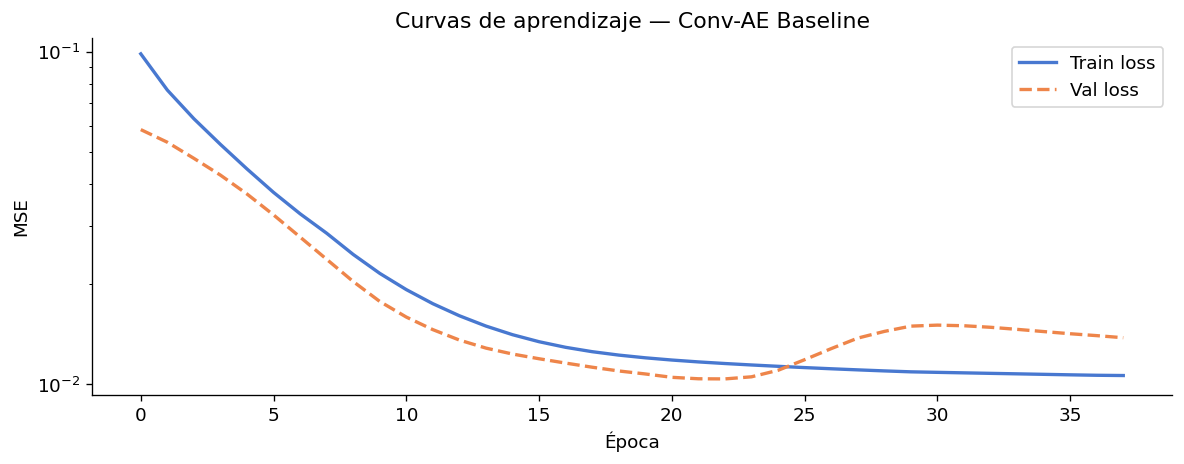

In [17]:
# ============================================================
# E5 — Entrenamiento
# ============================================================
# Por qué: el autoencoder se entrena exclusivamente sobre ventanas
# normales. El objetivo es minimizar el MSE de reconstrucción
# para que el modelo aprenda la distribución de datos normales.
# Las anomalías producirán errores de reconstrucción mayores,
# permitiendo su detección mediante un umbral calibrado.

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        '/kaggle/working/conv_ae_baseline_best.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )
]

print("Iniciando entrenamiento Conv-AE...")
print(f"  Épocas máx:  {EPOCHS} | Batch: {BATCH_SIZE} | LR: {LR} | Patience: {PATIENCE}")
print(f"  X_train: {X_train.shape} | X_val: {X_val.shape}")

t0 = time.time()
historial = modelo.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    shuffle=True,
    verbose=1
)
t_train = time.time() - t0

epocas_reales = len(historial.history['loss'])
mejor_val_loss = min(historial.history['val_loss'])

print(f"\nEntrenamiento completado en {t_train:.1f}s ({epocas_reales} épocas)")
print(f"Mejor val_loss: {mejor_val_loss:.6f}")

# Cargar mejor modelo guardado
modelo = tf.keras.models.load_model('/kaggle/working/conv_ae_baseline_best.keras')

# Curvas de aprendizaje
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(historial.history['loss'],     label='Train loss', linewidth=2)
ax.plot(historial.history['val_loss'], label='Val loss',   linewidth=2, linestyle='--')
ax.set_xlabel('Época')
ax.set_ylabel('MSE')
ax.set_title('Curvas de aprendizaje — Conv-AE Baseline')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/E5_curvas_entrenamiento.png', bbox_inches='tight', dpi=150)
plt.show()

## E6 — Evaluación baseline (fault injection + proxy DOD)

2026-07-12 17:08:45.684157: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


--- Métricas Fault Injection ---
  Umbral (p95 val): 0.017494
  F1:        0.3130
  Precision: 0.5143
  Recall:    0.2250
  AUC-ROC:   0.5684


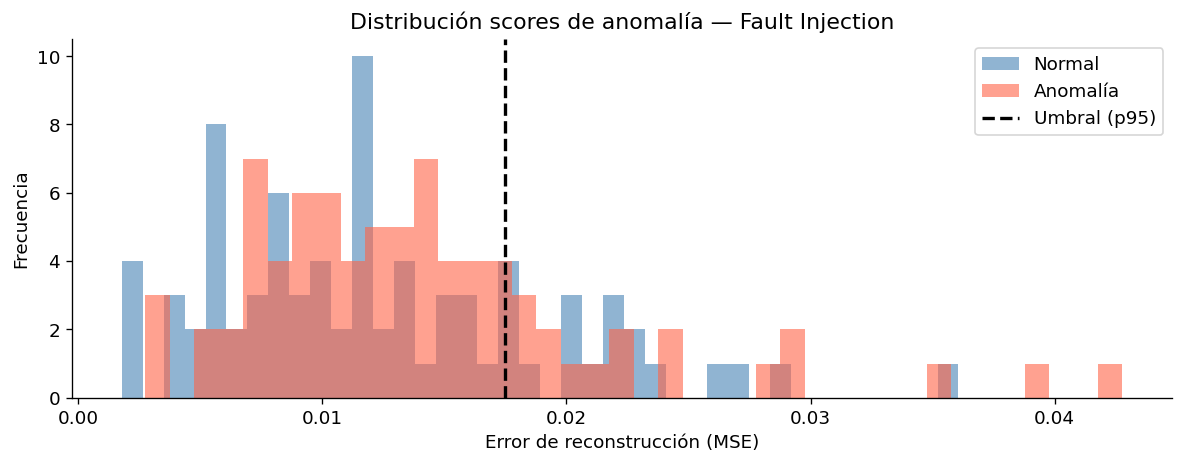


--- Proxy DOD ---
  Correlación score_medio ↔ días_hasta_DOD: 0.1074
  (Negativa esperada: mayor score → menos días hasta muerte)


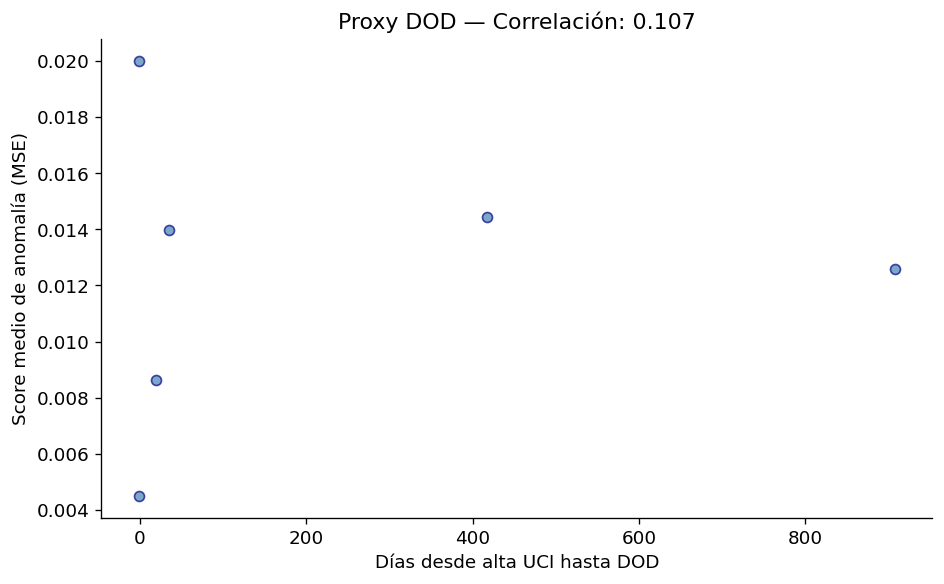

In [18]:
# ============================================================
# E6 — Evaluación baseline
# ============================================================
# Por qué: MIMIC-III Demo no tiene etiquetas de anomalía.
# Se usa el protocolo híbrido definido en el TFM
# (Mekki et al., 2026):
#
# (A) Fault injection — 3 tipos de anomalía sintética:
#     - Flatline: segmento plano (señal constante 8h)
#     - Dropout:  spike a 0 durante 2h
#     - Extremo:  valor fuera de rango fisiológico
#
# (B) Proxy DOD — correlación entre score de anomalía
#     y días desde alta UCI hasta fecha de fallecimiento.
#     Hipótesis: pacientes que fallecen pronto muestran
#     scores de anomalía más altos durante su estancia.

np.random.seed(SEED)

# ---- Funciones de inyección de anomalías ----

def inyectar_flatline(ventana, senal_idx, duracion=8):
    """Sustituye 'duracion' pasos por la media de la señal."""
    v = ventana.copy()
    inicio = np.random.randint(0, max(1, len(v) - duracion))
    v[inicio:inicio + duracion, senal_idx] = v[:, senal_idx].mean()
    return v

def inyectar_dropout(ventana, senal_idx, duracion=2):
    """Spike a 0 durante 'duracion' pasos."""
    v = ventana.copy()
    inicio = np.random.randint(0, max(1, len(v) - duracion))
    v[inicio:inicio + duracion, senal_idx] = 0.0
    return v

def inyectar_extremo(ventana, senal_idx):
    """Valor extremo: suma 1.5 a 4 pasos consecutivos (clip a [0,1])."""
    v = ventana.copy()
    inicio = np.random.randint(0, max(1, len(v) - 4))
    v[inicio:inicio + 4, senal_idx] = np.clip(
        v[inicio:inicio + 4, senal_idx] + 1.5, 0, 1
    )
    return v

TIPOS_ANOMALIA = [inyectar_flatline, inyectar_dropout, inyectar_extremo]

# ---- (A) Fault injection ----

n_eval   = len(X_test)
n_anomal = n_eval

X_anomalos = []
for _ in range(n_anomal):
    idx_base  = np.random.randint(0, len(X_train))
    tipo_fn   = np.random.choice(TIPOS_ANOMALIA)
    senal_idx = np.random.randint(0, N_SENALES)
    X_anomalos.append(tipo_fn(X_train[idx_base], senal_idx))
X_anomalos = np.array(X_anomalos)

X_eval_combined = np.vstack([X_test, X_anomalos])
y_eval_combined = np.array([0] * n_eval + [1] * n_anomal)

# Scores de anomalía (MSE por ventana)
X_recon = modelo.predict(X_eval_combined, batch_size=BATCH_SIZE, verbose=0)
scores  = np.mean((X_eval_combined - X_recon) ** 2, axis=(1, 2))

# Umbral calibrado en validación
scores_val = np.mean(
    (X_val - modelo.predict(X_val, batch_size=BATCH_SIZE, verbose=0)) ** 2,
    axis=(1, 2)
)
umbral = np.percentile(scores_val, UMBRAL_PCT)

y_pred = (scores > umbral).astype(int)

f1        = f1_score(y_eval_combined, y_pred, zero_division=0)
precision = precision_score(y_eval_combined, y_pred, zero_division=0)
recall    = recall_score(y_eval_combined, y_pred, zero_division=0)
auc       = roc_auc_score(y_eval_combined, scores)

print("--- Métricas Fault Injection ---")
print(f"  Umbral (p{UMBRAL_PCT} val): {umbral:.6f}")
print(f"  F1:        {f1:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  AUC-ROC:   {auc:.4f}")

# Distribución de scores
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(scores[y_eval_combined == 0], bins=40, alpha=0.6,
        label='Normal', color='steelblue')
ax.hist(scores[y_eval_combined == 1], bins=40, alpha=0.6,
        label='Anomalía', color='tomato')
ax.axvline(umbral, color='black', linestyle='--', linewidth=2,
           label=f'Umbral (p{UMBRAL_PCT})')
ax.set_xlabel('Error de reconstrucción (MSE)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución scores de anomalía — Fault Injection')
ax.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/E6_scores_distribucion.png', bbox_inches='tight', dpi=150)
plt.show()

# ---- (B) Proxy DOD ----
print("\n--- Proxy DOD ---")

patients = pd.read_csv(os.path.join(BASE_PATH, 'PATIENTS.csv'))
patients.columns = patients.columns.str.lower()
patients['dod'] = pd.to_datetime(patients['dod'], errors='coerce')

icustays_df = pd.read_csv(os.path.join(BASE_PATH, 'ICUSTAYS.csv'))
icustays_df.columns = icustays_df.columns.str.lower()
icustays_df['outtime'] = pd.to_datetime(icustays_df['outtime'], errors='coerce')

merged = icustays_df.merge(
    patients[['subject_id', 'dod']], on='subject_id', how='left'
)
merged['dias_hasta_dod'] = (
    (merged['dod'] - merged['outtime']).dt.total_seconds() / 86400
)

# Score medio de anomalía por paciente de test
scores_test = np.mean(
    (X_test - modelo.predict(X_test, batch_size=BATCH_SIZE, verbose=0)) ** 2,
    axis=(1, 2)
)

scores_por_pac = {}
idx = 0
for p in pac_test:
    if p not in series_pacientes:
        continue
    serie = series_pacientes[p]
    n_v = max(1, (len(serie) - VENTANA) // SOLAPAMIENTO + 1)
    n_v = min(n_v, len(scores_test) - idx)
    if n_v > 0:
        scores_por_pac[p] = scores_test[idx:idx + n_v].mean()
        idx += n_v

df_proxy = pd.DataFrame([
    {'subject_id': p, 'score_medio': s}
    for p, s in scores_por_pac.items()
])
df_proxy = df_proxy.merge(
    merged[['subject_id', 'dias_hasta_dod']].drop_duplicates('subject_id'),
    on='subject_id', how='left'
).dropna(subset=['dias_hasta_dod'])

if len(df_proxy) >= 3:
    corr = df_proxy[['score_medio', 'dias_hasta_dod']].corr().iloc[0, 1]
    print(f"  Correlación score_medio ↔ días_hasta_DOD: {corr:.4f}")
    print(f"  (Negativa esperada: mayor score → menos días hasta muerte)")

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(df_proxy['dias_hasta_dod'], df_proxy['score_medio'],
               alpha=0.7, color='steelblue', edgecolors='navy')
    ax.set_xlabel('Días desde alta UCI hasta DOD')
    ax.set_ylabel('Score medio de anomalía (MSE)')
    ax.set_title(f'Proxy DOD — Correlación: {corr:.3f}')
    plt.tight_layout()
    plt.savefig('/kaggle/working/E6_proxy_dod.png', bbox_inches='tight', dpi=150)
    plt.show()
else:
    corr = None
    print("  Pacientes test insuficientes para proxy DOD (limitación demo).")

## E7 — Métricas de referencia y exportación del modelo

In [19]:
# ============================================================
# E7 — Métricas de referencia y exportación del modelo
# ============================================================
# Por qué: consolida las 4 métricas baseline que servirán como
# referencia para la comparativa de técnicas Edge AI (OE3):
#   1. Tamaño del modelo (KB)
#   2. F1 sobre fault injection
#   3. Latencia de inferencia Python (ms/ventana)
#   4. RAM estimada en ESP8266 (KB)
# El modelo se exporta en .keras y TFLite float32.

# -- 1. Guardar modelo Keras --
modelo.save('/kaggle/working/conv_ae_baseline.keras')
tam_keras_kb = os.path.getsize('/kaggle/working/conv_ae_baseline.keras') / 1024

# -- 2. Exportar a TFLite float32 --
converter = tf.lite.TFLiteConverter.from_keras_model(modelo)
tflite_f32 = converter.convert()
with open('/kaggle/working/conv_ae_baseline_f32.tflite', 'wb') as f:
    f.write(tflite_f32)
tam_tflite_f32_kb  = len(tflite_f32) / 1024
tam_int8_est_kb    = tam_tflite_f32_kb / 4
ram_esp8266_est_kb = tam_int8_est_kb * 2  # pesos + tensor arena

# -- 3. Latencia de inferencia (100 repeticiones, 1 ventana) --
ventana_ref = X_test[:1]
for _ in range(10):  # warm-up
    modelo.predict(ventana_ref, verbose=0)

tiempos_lat = []
for _ in range(100):
    t_i = time.perf_counter()
    modelo.predict(ventana_ref, verbose=0)
    tiempos_lat.append((time.perf_counter() - t_i) * 1000)

lat_media_ms = np.mean(tiempos_lat)
lat_p95_ms   = np.percentile(tiempos_lat, 95)

# -- 4. Tabla de métricas baseline --
metricas_baseline = {
    'arquitectura':              'Conv-AE (Conv1D Autoencoder)',
    'parametros':                int(modelo.count_params()),
    'tam_keras_kb':              round(tam_keras_kb, 2),
    'tam_tflite_f32_kb':         round(tam_tflite_f32_kb, 2),
    'tam_int8_estimado_kb':      round(tam_int8_est_kb, 2),
    'ram_esp8266_estimada_kb':   round(ram_esp8266_est_kb, 2),
    'f1_fault_injection':        round(float(f1), 4),
    'precision':                 round(float(precision), 4),
    'recall':                    round(float(recall), 4),
    'auc_roc':                   round(float(auc), 4),
    'corr_proxy_dod':            round(float(corr), 4) if corr is not None else None,
    'latencia_media_ms':         round(lat_media_ms, 2),
    'latencia_p95_ms':           round(lat_p95_ms, 2),
    'umbral_anomalia':           round(float(umbral), 6),
    'epocas_entrenamiento':      epocas_reales,
    'mejor_val_loss':            round(float(mejor_val_loss), 6),
    'restriccion_ram_kb':        60,
    'restriccion_latencia_ms':   500,
    'degradacion_f1_max_pct':    10,
    'cumple_ram':                ram_esp8266_est_kb < 60,
    'cumple_latencia_python':    lat_media_ms < 500
}

print("=" * 65)
print("MÉTRICAS BASELINE — Conv-AE")
print("=" * 65)
for k, v in metricas_baseline.items():
    print(f"  {k:<38}: {v}")
print("=" * 65)

# Guardar métricas — convertir tipos numpy a Python nativos
def convertir_tipos(obj):
    if isinstance(obj, (np.bool_, bool)):
        return bool(obj)
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    return obj

metricas_serializables = {k: convertir_tipos(v) for k, v in metricas_baseline.items()}

with open('/kaggle/working/metricas_baseline.json', 'w', encoding='utf-8') as f:
    json.dump(metricas_serializables, f, ensure_ascii=False, indent=2)

# Actualizar config con arquitectura confirmada
with open('/kaggle/working/config_modelo_base.json', 'r', encoding='utf-8') as f:
    config_final = json.load(f)
config_final['arquitectura'] = 'Conv-AE (Conv1D Autoencoder)'
config_final['input_shape']  = f'({VENTANA}, {N_SENALES})'
with open('/kaggle/working/config_modelo_base.json', 'w', encoding='utf-8') as f:
    json.dump(config_final, f, ensure_ascii=False, indent=2)

print("Archivos guardados en /kaggle/working/:")
print("  conv_ae_baseline.keras")
print("  conv_ae_baseline_f32.tflite")
print("  metricas_baseline.json")
print("  config_modelo_base.json  (actualizado)")

print("\n--- Verificación restricciones ESP8266 ---")
print(f"  RAM estimada:  {ram_esp8266_est_kb:.2f} KB  "
      f"{'✅' if ram_esp8266_est_kb < 60 else '❌'}  (límite 60 KB)")
print(f"  Latencia:      {lat_media_ms:.2f} ms  "
      f"{'✅' if lat_media_ms < 500 else '⚠️'}  (límite 500 ms)")
print(f"  F1 baseline:   {f1:.4f}")
print(f"  F1 mín. OE3:   {f1 * 0.90:.4f}  (degradación ≤ 10%)")

INFO:tensorflow:Assets written to: /tmp/tmpde4zvmfj/assets


INFO:tensorflow:Assets written to: /tmp/tmpde4zvmfj/assets


Saved artifact at '/tmp/tmpde4zvmfj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 24, 6), dtype=tf.float32, name='input')
Output Type:
  TensorSpec(shape=(None, 24, 6), dtype=tf.float32, name=None)
Captures:
  138619937099216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138619937096336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138619937099024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138619837949392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138619937096720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138619937098832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138619837950352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138619837949008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138619837950544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138619837949968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138619837947280: Tensor

W0000 00:00:1783876127.974138      58 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1783876127.974177      58 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-07-12 17:08:50.707454: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-07-12 17:08:55.734901: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions

MÉTRICAS BASELINE — Conv-AE
  arquitectura                          : Conv-AE (Conv1D Autoencoder)
  parametros                            : 5102
  tam_keras_kb                          : 130.11
  tam_tflite_f32_kb                     : 34.7
  tam_int8_estimado_kb                  : 8.68
  ram_esp8266_estimada_kb               : 17.35
  f1_fault_injection                    : 0.313
  precision                             : 0.5143
  recall                                : 0.225
  auc_roc                               : 0.5684
  corr_proxy_dod                        : 0.1074
  latencia_media_ms                     : 78.41
  latencia_p95_ms                       : 82.63
  umbral_anomalia                       : 0.017494
  epocas_entrenamiento                  : 38
  mejor_val_loss                        : 0.010383
  restriccion_ram_kb                    : 60
  restriccion_latencia_ms               : 500
  degradacion_f1_max_pct                : 10
  cumple_ram                            :

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 5.1 MB/s eta 0:00:00
Verificación baseline


2026-07-12 17:09:04.361045: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


F1=0.5942 | Precisión=0.7069 | Recall=0.5125
F1 mínimo aceptable Fase 2: 0.5348

TÉCNICA 1 — Cuantización INT8
INFO:tensorflow:Assets written to: /tmp/tmpt9wm1bae/assets


INFO:tensorflow:Assets written to: /tmp/tmpt9wm1bae/assets


Saved artifact at '/tmp/tmpt9wm1bae'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 24, 6), dtype=tf.float32, name='input')
Output Type:
  TensorSpec(shape=(None, 24, 6), dtype=tf.float32, name=None)
Captures:
  138619937099216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138619937096336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138619937099024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138619837949392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138619937096720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138619937098832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138619837950352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138619837949008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138619837950544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138619837949968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138619837947280: Tensor

...

    Época  30 | train=0.00769 | val=0.01189
    Época  40 | train=0.00652 | val=0.01294
    Early stopping en época 46
  Mejor val_loss: 0.011500
INFO:tensorflow:Assets written to: /tmp/tmp1_etx28i/assets


INFO:tensorflow:Assets written to: /tmp/tmp1_etx28i/assets


Saved artifact at '/tmp/tmp1_etx28i'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 24, 6), dtype=tf.float32, name='keras_tensor_48')
Output Type:
  TensorSpec(shape=(None, 24, 6), dtype=tf.float32, name=None)
Captures:
  138619842475408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138619842474832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138619842472912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138619842472144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138619842472336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138619842471376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138619842472528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138619842474448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138619842470800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138619842474640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1386198424706

W0000 00:00:1783876165.560084      58 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1783876165.560119      58 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


  tecnica3_distillation_int8: 17.92 KB | RAM est. 35.84 KB
  F1=0.5496 (Δ=-0.0446) | AUC=0.6702
  Latencia media: 0.02 ms
  Reducción vs INT8: 6.73 KB (27.3%)
  RAM: ✅ | F1: ✅

OE5 — Generando artefactos para ESP8266
  Mejor técnica: Destilación + INT8 | 17.92 KB | F1=0.5496
  Operadores del modelo final: ['ADD', 'CONCATENATION', 'CONV_2D', 'EXPAND_DIMS', 'LOGISTIC', 'MAX_POOL_2D', 'MUL', 'RESHAPE', 'SHAPE', 'STRIDED_SLICE', 'TRANSPOSE_CONV']
  ✅ conv_ae_model_data.h generado (SIN PROGMEM)
  ✅ esp8266_benchmark.ino generado (Chirale_TensorFlowLite + MicroMutableOpResolver)
  → Resolver configurado con 11 operadores: ['AddAdd', 'AddConcatenation', 'AddConv2D', 'AddExpandDims', 'AddLogistic', 'AddMaxPool2D', 'AddMul', 'AddReshape', 'AddShape', 'AddStridedSlice', 'AddTransposeConv']
  → Flashear en NodeMCU, abrir monitor serie a 115200 baud, anotar latencia media para OE5
  → Si AllocateTensors() falla, aumentar kArenaSize en pasos de 2 KB
  → Placa recomendada en Arduino IDE: 'Generic ES

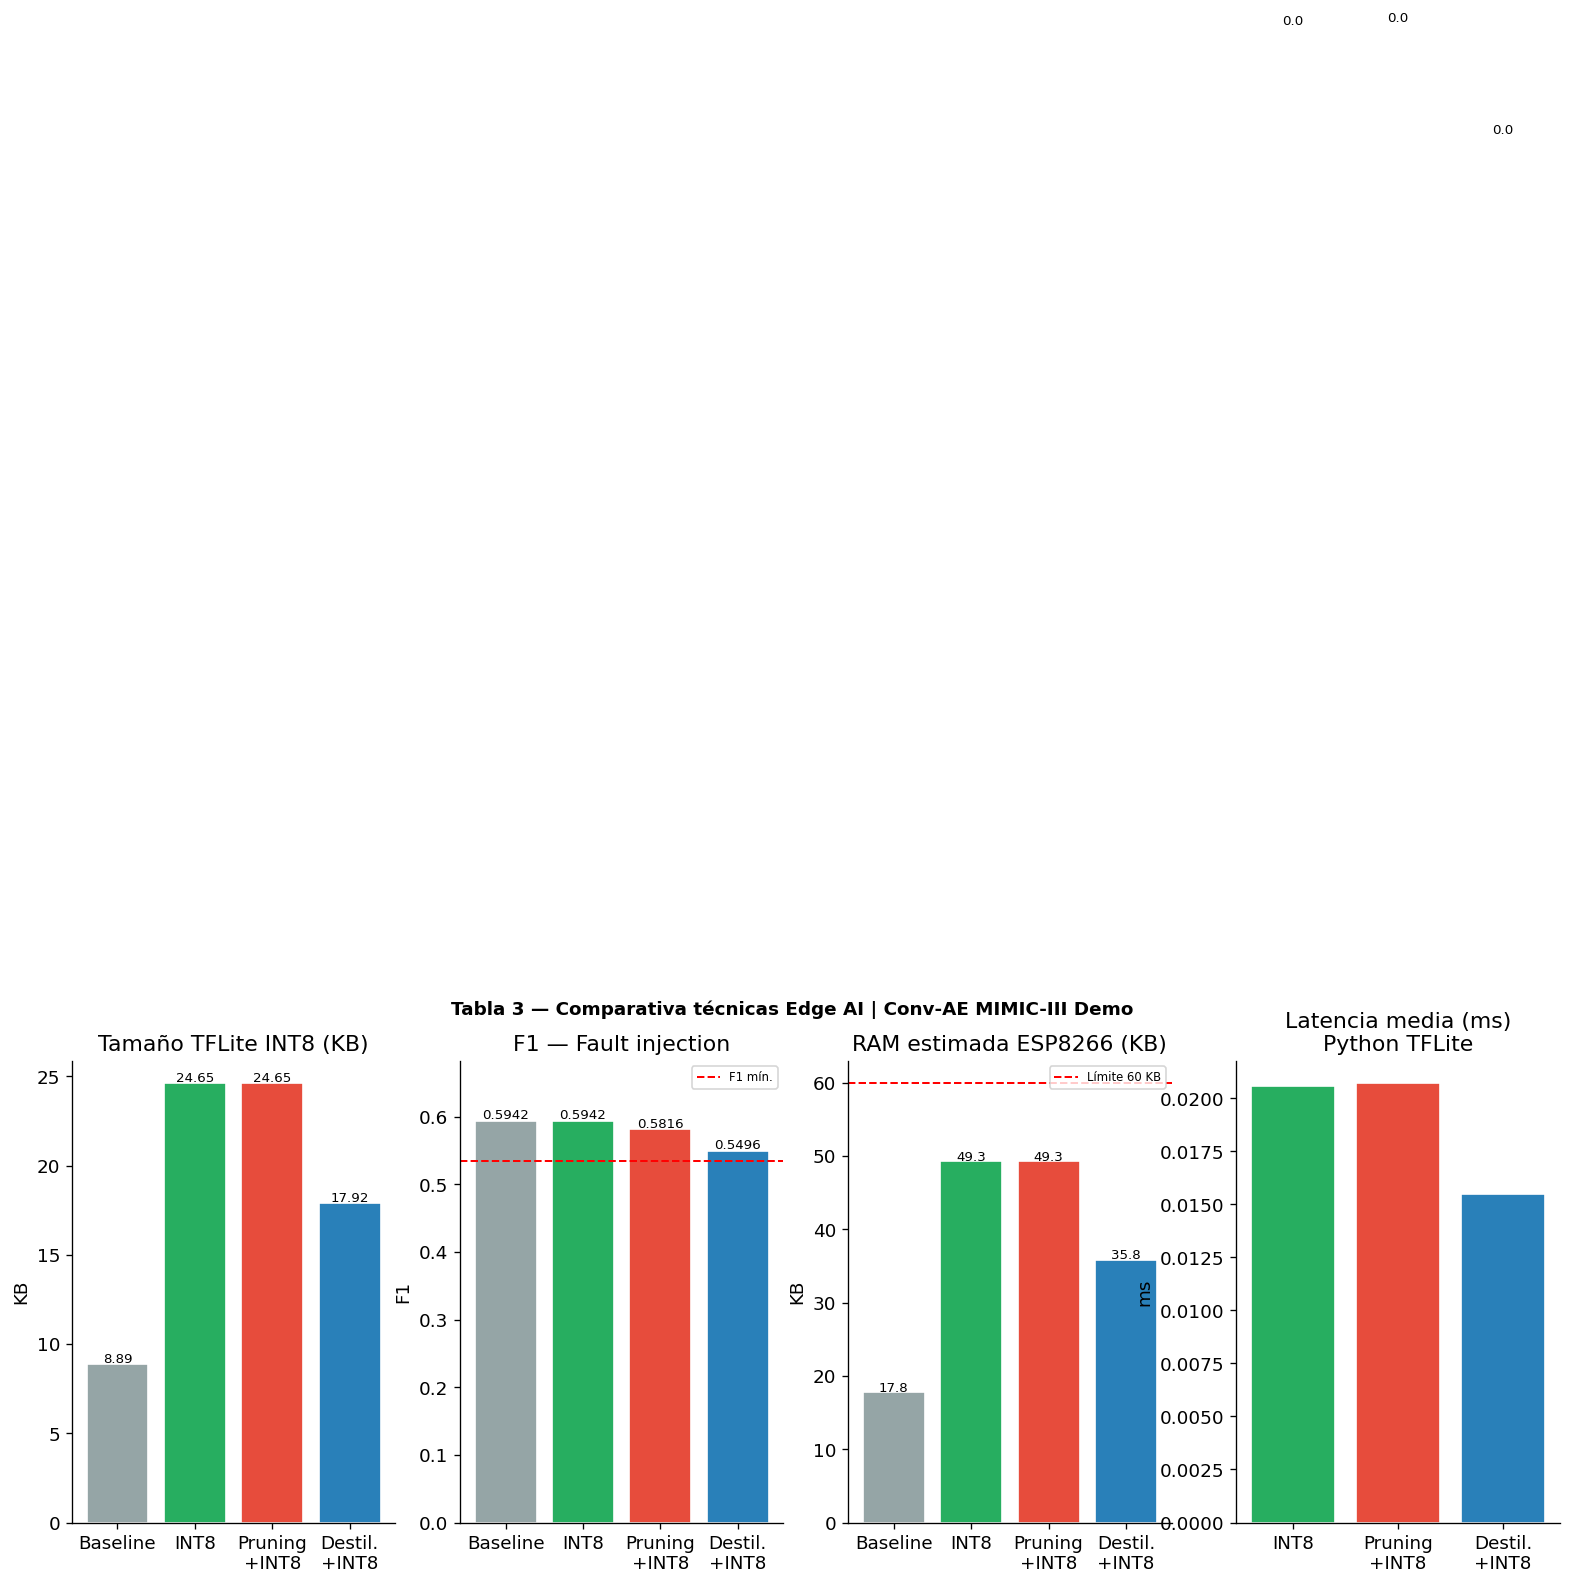


✅ Outputs en /kaggle/working/fase2_outputs/:
   📊 resultados_fase2.json
   📈 figura3_comparativa.png
   💾 tecnica1_int8.tflite
   💾 tecnica2_pruning_int8.tflite
   💾 tecnica3_distillation_int8.tflite
   🔌 conv_ae_model_data.h  ← para ESP8266 (SIN PROGMEM)
   🔌 esp8266_benchmark.ino ← flashear en NodeMCU para OE5 (Chirale + MicroMutableOpResolver)

⏭️  Próximo paso: flashear sketch en ESP8266 (placa 'Generic ESP8266 Module'),
    anotar latencia media del Serial Monitor (115200 baud).
    Luego actualizar Cap. 5.3 y 7 de la memoria con el valor real.


In [20]:
# ================================================================
# FASE 2 — Comparativa de técnicas Edge AI
# Pegar al final del notebook de Fase 1
# ================================================================
# Asume que ya existen en memoria (definidos en Fase 1):
#   modelo   → modelo Keras Conv-AE entrenado (E5), variable
#              renombrada de "baseline" para coherencia con Fase 1
#   construir_conv_ae → función de arquitectura (E4), renombrada
#              de "build_conv_ae" para coherencia con Fase 1
#   X_train, X_val, X_test → ventanas normalizadas (n, 24, 6)
#   SEED = 42
#
# CORRECCIÓN (revisión julio 2026):
#   1. Esta celda usaba el nombre "baseline" para el modelo
#      entrenado y "build_conv_ae" para la función de arquitectura,
#      pero en Fase 1 (E4/E5) estas variables se llaman "modelo" y
#      "construir_conv_ae". Se corrige la referencia para que la
#      celda funcione en el notebook unificado sin renombrar nada
#      manualmente entre Fase 1 y Fase 2.
#   2. build_student() tenía un bug: usaba las variables F y K sin
#      definir en las líneas de Conv1DTranspose (NameError
#      garantizado). Se corrige especificando filtros y kernel_size
#      explícitos, coherentes con la arquitectura del teacher.
#   3. El sketch de Arduino generado automáticamente usaba
#      esp-tflite-micro + AllOpsResolver, librería que NO soporta
#      ESP8266 (requiere ESP-IDF, solo disponible para ESP32/S/C
#      — confirmado en documentación oficial del repositorio,
#      espressif/esp-tflite-micro). Se sustituye por
#      Chirale_TensorFlowLite + MicroMutableOpResolver con los
#      operadores reales del modelo (verificados por inspección
#      del flatbuffer), único camino que ha funcionado empíricamente
#      sobre este hardware (ver Anexo D).
# ================================================================

import time, json, os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

try:
    import tensorflow_model_optimization as tfmot
except ImportError:
    os.system("pip install tensorflow_model_optimization -q")
    import tensorflow_model_optimization as tfmot

OUTPUT_DIR = '/kaggle/working/fase2_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

WINDOW_SIZE = 24
N_SIGNALS   = 6
F1_BASELINE = None   # se calcula abajo

# Alias de compatibilidad: el resto de esta celda usa "baseline"
# como nombre corto interno; se referencia al "modelo" real de Fase 1.
baseline = modelo

# ================================================================
# FUNCIONES COMPARTIDAS
# ================================================================

def inject_anomalies(windows, seed=SEED):
    """
    Inyecta anomalías sintéticas en ventanas normales.
      Tipo 0 — Flatline:       señal constante 8 pasos
      Tipo 1 — Dropout:        señal a 0 durante 2 pasos
      Tipo 2 — Fuera de rango: valor fuera de [0,1] durante 4 pasos
    """
    rng  = np.random.RandomState(seed)
    anom = windows.copy()
    for i in range(len(anom)):
        sig = rng.randint(0, N_SIGNALS)
        t   = rng.randint(0, 3)
        if t == 0:
            s = rng.randint(0, WINDOW_SIZE - 8)
            anom[i, s:s+8, sig] = anom[i, s, sig]
        elif t == 1:
            s = rng.randint(0, WINDOW_SIZE - 2)
            anom[i, s:s+2, sig] = 0.0
        else:
            s = rng.randint(0, WINDOW_SIZE - 4)
            anom[i, s:s+4, sig] = -0.3 if rng.rand() < 0.5 else 1.3
    return anom


def compute_threshold(model, X_val, percentile=95):
    """Umbral = percentil 95 MSE sobre ventanas normales de validación."""
    recon = model.predict(X_val, verbose=0)
    mse   = np.mean(np.square(X_val - recon), axis=(1, 2))
    return float(np.percentile(mse, percentile))


def evaluate_keras(model, X_test, threshold):
    """Evaluación con protocolo fault injection sobre modelo Keras."""
    X_anom = inject_anomalies(X_test)
    X_eval = np.concatenate([X_test, X_anom])
    y_true = np.array([0]*len(X_test) + [1]*len(X_anom))
    recon  = model.predict(X_eval, verbose=0)
    mse    = np.mean(np.square(X_eval - recon), axis=(1, 2))
    y_pred = (mse > threshold).astype(int)
    return dict(
        f1        = f1_score(y_true, y_pred, zero_division=0),
        precision = precision_score(y_true, y_pred, zero_division=0),
        recall    = recall_score(y_true, y_pred, zero_division=0),
        auc_roc   = roc_auc_score(y_true, mse),
    )


def tflite_threshold(tflite_bytes, X_val, percentile=95):
    """Umbral calculado con intérprete TFLite sobre validación."""
    interp = tf.lite.Interpreter(model_content=tflite_bytes)
    interp.allocate_tensors()
    id_ = interp.get_input_details()[0]
    od_ = interp.get_output_details()[0]
    is8 = id_['dtype'] == np.int8
    isc, izp = id_['quantization']
    osc, ozp = od_['quantization']
    mse_val = []
    for win in X_val:
        inp = win.reshape(1, WINDOW_SIZE, N_SIGNALS).astype(np.float32)
        if is8:
            inp = np.clip(inp / isc + izp, -128, 127).astype(np.int8)
        interp.set_tensor(id_['index'], inp)
        interp.invoke()
        out = interp.get_tensor(od_['index'])
        if is8:
            out = (out.astype(np.float32) - ozp) * osc
        mse_val.append(np.mean(np.square(win - out[0])))
    return float(np.percentile(mse_val, percentile))


def evaluate_tflite(tflite_bytes, X_test, threshold):
    """Evaluación completa + latencia sobre modelo TFLite INT8."""
    interp = tf.lite.Interpreter(model_content=tflite_bytes)
    interp.allocate_tensors()
    id_ = interp.get_input_details()[0]
    od_ = interp.get_output_details()[0]
    is8 = id_['dtype'] == np.int8
    isc, izp = id_['quantization']
    osc, ozp = od_['quantization']

    X_anom = inject_anomalies(X_test)
    X_eval = np.concatenate([X_test, X_anom])
    y_true = np.array([0]*len(X_test) + [1]*len(X_anom))

    mse_list, lats = [], []
    for win in X_eval:
        inp = win.reshape(1, WINDOW_SIZE, N_SIGNALS).astype(np.float32)
        if is8:
            inp = np.clip(inp / isc + izp, -128, 127).astype(np.int8)
        interp.set_tensor(id_['index'], inp)
        t0 = time.perf_counter()
        interp.invoke()
        lats.append((time.perf_counter() - t0) * 1000)
        out = interp.get_tensor(od_['index'])
        if is8:
            out = (out.astype(np.float32) - ozp) * osc
        mse_list.append(np.mean(np.square(win - out[0])))

    mse  = np.array(mse_list)
    pred = (mse > threshold).astype(int)
    return dict(
        f1          = f1_score(y_true, pred, zero_division=0),
        precision   = precision_score(y_true, pred, zero_division=0),
        recall      = recall_score(y_true, pred, zero_division=0),
        auc_roc     = roc_auc_score(y_true, mse),
        lat_mean_ms = float(np.mean(lats)),
        lat_p95_ms  = float(np.percentile(lats, 95)),
    )


def to_int8(model, X_train, name):
    """Convierte modelo Keras a TFLite INT8 (PTQ) y lo guarda."""
    def rep():
        idx = np.random.RandomState(SEED).choice(len(X_train), min(200, len(X_train)), replace=False)
        for i in idx:
            yield [X_train[i:i+1].astype(np.float32)]
    c = tf.lite.TFLiteConverter.from_keras_model(model)
    c.optimizations = [tf.lite.Optimize.DEFAULT]
    c.representative_dataset = rep
    c.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    c.inference_input_type  = tf.int8
    c.inference_output_type = tf.int8
    tfl = c.convert()
    with open(os.path.join(OUTPUT_DIR, f'{name}.tflite'), 'wb') as f:
        f.write(tfl)
    kb  = len(tfl) / 1024
    ram = kb * 2
    print(f"  {name}: {kb:.2f} KB | RAM est. {ram:.2f} KB")
    return tfl, kb, ram


def obtener_operadores_tflite(tflite_bytes):
    """
    Inspecciona el flatbuffer .tflite y devuelve el conjunto de
    operadores reales (sin fusión de delegates), tal como los verá
    el intérprete TFLM en el microcontrolador. Necesario para
    generar el resolver MicroMutableOpResolver con los operadores
    exactos, en lugar de AllOpsResolver (128 ops, coste fijo de RAM
    ~30.7 KB medido empíricamente en este proyecto).
    """
    interp = tf.lite.Interpreter(
        model_content=tflite_bytes,
        experimental_op_resolver_type=(
            tf.lite.experimental.OpResolverType.BUILTIN_WITHOUT_DEFAULT_DELEGATES
        )
    )
    interp.allocate_tensors()
    ops = set()
    for op_details in interp._get_ops_details():
        ops.add(op_details['op_name'])
    return ops


# Mapeo de nombre de operador TFLite -> método AddXxx() de
# MicroMutableOpResolver (tensorflow/lite/micro/micro_mutable_op_resolver.h).
# Cubre los operadores esperables para un Conv-AE con Conv1DTranspose;
# ampliar si el modelo final usa operadores adicionales.
MAPEO_OPERADOR_A_METODO = {
    'ADD':             'AddAdd',
    'CONCATENATION':   'AddConcatenation',
    'CONV_2D':         'AddConv2D',
    'EXPAND_DIMS':     'AddExpandDims',
    'LOGISTIC':        'AddLogistic',
    'MAX_POOL_2D':     'AddMaxPool2D',
    'MUL':             'AddMul',
    'RESHAPE':         'AddReshape',
    'SHAPE':           'AddShape',
    'STRIDED_SLICE':   'AddStridedSlice',
    'TILE':            'AddTile',  # no debería aparecer tras la corrección
    'TRANSPOSE_CONV':  'AddTransposeConv',
    'QUANTIZE':        'AddQuantize',
    'DEQUANTIZE':      'AddDequantize',
    'PAD':             'AddPad',
    'MEAN':            'AddMean',
    'SUB':             'AddSub',
}


# ================================================================
# VERIFICACIÓN BASELINE (coherencia con Fase 1)
# ================================================================
print("=" * 55)
print("Verificación baseline")
thr_base  = compute_threshold(baseline, X_val)
eval_base = evaluate_keras(baseline, X_test, thr_base)
F1_BASELINE = eval_base['f1']
F1_MIN      = F1_BASELINE * 0.90
print(f"F1={F1_BASELINE:.4f} | Precisión={eval_base['precision']:.4f} | Recall={eval_base['recall']:.4f}")
print(f"F1 mínimo aceptable Fase 2: {F1_MIN:.4f}")

RESULTS = {
    'Baseline': {
        'size_kb': 8.89, 'ram_kb': 17.79,
        'f1': F1_BASELINE, 'lat_mean_ms': None,
        'cumple_ram': True, 'cumple_f1': True,
    }
}

# ================================================================
# TÉCNICA 1 — Cuantización INT8
# ================================================================
print("\n" + "=" * 55)
print("TÉCNICA 1 — Cuantización INT8")

tfl_t1, sz_t1, ram_t1 = to_int8(baseline, X_train, 'tecnica1_int8')
thr_t1  = tflite_threshold(tfl_t1, X_val)
ev_t1   = evaluate_tflite(tfl_t1, X_test, thr_t1)

print(f"  F1={ev_t1['f1']:.4f} (Δ={ev_t1['f1']-F1_BASELINE:+.4f}) | AUC={ev_t1['auc_roc']:.4f}")
print(f"  Latencia media: {ev_t1['lat_mean_ms']:.2f} ms | p95: {ev_t1['lat_p95_ms']:.2f} ms")
print(f"  RAM: {'✅' if ram_t1 < 60 else '❌'} | F1: {'✅' if ev_t1['f1'] >= F1_MIN else '❌'}")

RESULTS['INT8'] = {**ev_t1, 'size_kb': sz_t1, 'ram_kb': ram_t1,
                   'cumple_ram': ram_t1 < 60, 'cumple_f1': ev_t1['f1'] >= F1_MIN}

# ================================================================
# TÉCNICA 2 — Podado por magnitud manual + INT8
# TFMOT incompatible con Keras 3. Implementación equivalente:
# zeroing de pesos por magnitud (50% sparsity) + reentrenamiento.
# ================================================================
print("\n" + "=" * 55)
print("TÉCNICA 2 — Podado por magnitud + INT8")

import copy

# Reconstruir modelo fresco con los pesos del baseline.
# Se usa construir_conv_ae (definida en E4, Fase 1), no build_conv_ae
# (nombre inexistente en el notebook unificado).
modelo_podado = construir_conv_ae(VENTANA, N_SENALES, lr=LR, seed=SEED)
modelo_podado.set_weights(baseline.get_weights())

# Aplicar máscara de sparsity 50% por magnitud en pesos Conv1D
# (incluye Conv1DTranspose, subclase de Conv1D en Keras 3)
FINAL_SPARSITY = 0.50
total_pruned = 0
total_weights = 0

for layer in modelo_podado.layers:
    if isinstance(layer, (tf.keras.layers.Conv1D, tf.keras.layers.Conv1DTranspose)):
        weights = layer.get_weights()  # [kernel, bias]
        kernel = weights[0]
        flat = np.abs(kernel.flatten())
        threshold = np.percentile(flat, FINAL_SPARSITY * 100)
        mask = (np.abs(kernel) >= threshold).astype(np.float32)
        weights[0] = kernel * mask
        layer.set_weights(weights)
        total_pruned  += np.sum(mask == 0)
        total_weights += mask.size

sparsity_real = total_pruned / total_weights
print(f"  Sparsity real aplicada: {sparsity_real*100:.1f}%")

# Reentrenar para recuperar accuracy tras podado
modelo_podado.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss='mse')
modelo_podado.fit(
    X_train, X_train,
    epochs=20, batch_size=32,
    validation_data=(X_val, X_val),
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1,
)

tfl_t2, sz_t2, ram_t2 = to_int8(modelo_podado, X_train, 'tecnica2_pruning_int8')
thr_t2 = tflite_threshold(tfl_t2, X_val)
ev_t2  = evaluate_tflite(tfl_t2, X_test, thr_t2)

print(f"  F1={ev_t2['f1']:.4f} (Δ={ev_t2['f1']-F1_BASELINE:+.4f}) | AUC={ev_t2['auc_roc']:.4f}")
print(f"  Latencia media: {ev_t2['lat_mean_ms']:.2f} ms")
print(f"  RAM: {'✅' if ram_t2 < 60 else '❌'} | F1: {'✅' if ev_t2['f1'] >= F1_MIN else '❌'}")

RESULTS['Pruning 50% + INT8'] = {**ev_t2, 'size_kb': sz_t2, 'ram_kb': ram_t2,
                                  'sparsity': sparsity_real,
                                  'cumple_ram': ram_t2 < 60, 'cumple_f1': ev_t2['f1'] >= F1_MIN}

# ================================================================
# TÉCNICA 3 — Destilación de conocimiento + INT8
# ================================================================
print("\n" + "=" * 55)
print("TÉCNICA 3 — Destilación de conocimiento + INT8")

def build_student():
    """Student Conv-AE — filtros a la mitad del teacher (~31% params).

    CORRECCIÓN: la versión previa de esta función usaba
    layers.Conv1DTranspose(filters=F, kernel_size=K, ...) con F y K
    sin definir, lo que provocaba NameError al ejecutarse. Se fijan
    los valores explícitos (16 y 8 filtros, kernel_size=3), simétricos
    con el encoder del propio student y coherentes con el patrón de
    reducción a la mitad respecto al teacher (32/16/8 → 16/8/4).
    """
    inp = tf.keras.Input(shape=(WINDOW_SIZE, N_SIGNALS))
    x = tf.keras.layers.Conv1D(16, 3, padding='same', activation='relu')(inp)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    x = tf.keras.layers.Conv1D(8,  3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)
    x = tf.keras.layers.Conv1D(4,  3, padding='same', activation='relu')(x)  # bottleneck
    x = tf.keras.layers.Conv1DTranspose(8, kernel_size=3, strides=2,
                                         padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv1DTranspose(16, kernel_size=3, strides=2,
                                         padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    out = tf.keras.layers.Conv1D(N_SIGNALS, 1, padding='same', activation='sigmoid')(x)
    return tf.keras.Model(inp, out, name='student')

student   = build_student()
optimizer = tf.keras.optimizers.Adam(1e-3)
print(f"  Student: {student.count_params()} params ({student.count_params()/baseline.count_params()*100:.1f}% del teacher)")

ALPHA        = 0.5
DIST_EPOCHS  = 60
DIST_BATCH   = 32
PATIENCE_MAX = 12
best_val     = float('inf')
patience     = 0

train_ds = (tf.data.Dataset.from_tensor_slices(X_train)
            .shuffle(1024, seed=SEED).batch(DIST_BATCH))

@tf.function
def distill_step(Xb):
    with tf.GradientTape() as tape:
        t_out = baseline(Xb, training=False)
        s_out = student(Xb, training=True)
        loss  = (ALPHA * tf.reduce_mean(tf.square(Xb - s_out))
                 + (1 - ALPHA) * tf.reduce_mean(tf.square(t_out - s_out)))
    grads = tape.gradient(loss, student.trainable_variables)
    optimizer.apply_gradients(zip(grads, student.trainable_variables))
    return loss

print(f"  Entrenando (α={ALPHA}, máx {DIST_EPOCHS} épocas)...")
train_losses = []
val_losses   = []
for epoch in range(DIST_EPOCHS):
    train_loss = np.mean([distill_step(Xb).numpy() for Xb in train_ds])
    val_recon  = student.predict(X_val, verbose=0)
    val_loss   = float(np.mean(np.square(X_val - val_recon)))
    train_losses.append(float(train_loss))
    val_losses.append(val_loss)

    if (epoch + 1) % 10 == 0:
        print(f"    Época {epoch+1:3d} | train={train_loss:.5f} | val={val_loss:.5f}")

    if val_loss < best_val - 1e-6:
        best_val = val_loss
        patience = 0
        student.save_weights(os.path.join(OUTPUT_DIR, 'student_best.weights.h5'))
    else:
        patience += 1
        if patience % 5 == 0:
            optimizer.learning_rate.assign(max(float(optimizer.learning_rate) * 0.5, 1e-6))
        if patience >= PATIENCE_MAX:
            print(f"    Early stopping en época {epoch+1}")
            break

student.load_weights(os.path.join(OUTPUT_DIR, 'student_best.weights.h5'))
print(f"  Mejor val_loss: {best_val:.6f}")

tfl_t3, sz_t3, ram_t3 = to_int8(student, X_train, 'tecnica3_distillation_int8')
thr_t3  = tflite_threshold(tfl_t3, X_val)
ev_t3   = evaluate_tflite(tfl_t3, X_test, thr_t3)

print(f"  F1={ev_t3['f1']:.4f} (Δ={ev_t3['f1']-F1_BASELINE:+.4f}) | AUC={ev_t3['auc_roc']:.4f}")
print(f"  Latencia media: {ev_t3['lat_mean_ms']:.2f} ms")
print(f"  Reducción vs INT8: {sz_t1-sz_t3:.2f} KB ({(1-sz_t3/sz_t1)*100:.1f}%)")
print(f"  RAM: {'✅' if ram_t3 < 60 else '❌'} | F1: {'✅' if ev_t3['f1'] >= F1_MIN else '❌'}")

RESULTS['Destilación + INT8'] = {**ev_t3, 'size_kb': sz_t3, 'ram_kb': ram_t3,
                                  'cumple_ram': ram_t3 < 60, 'cumple_f1': ev_t3['f1'] >= F1_MIN}

# ================================================================
# OE5 — Preparación hardware ESP8266
# ================================================================
print("\n" + "=" * 55)
print("OE5 — Generando artefactos para ESP8266")

# Seleccionar mejor modelo viable
viable = {n: r for n, r in RESULTS.items()
          if n != 'Baseline' and r['cumple_ram'] and r['cumple_f1']}
best_name = min(viable, key=lambda n: viable[n]['size_kb']) if viable else 'INT8'
best_tfl  = {'INT8': tfl_t1, 'Pruning 50% + INT8': tfl_t2, 'Destilación + INT8': tfl_t3}[best_name]

print(f"  Mejor técnica: {best_name} | {RESULTS[best_name]['size_kb']:.2f} KB | F1={RESULTS[best_name]['f1']:.4f}")

# Verificar compatibilidad TFLM real del modelo final seleccionado
# y obtener el conjunto exacto de operadores para el resolver.
ops_modelo_final = obtener_operadores_tflite(best_tfl)
print(f"  Operadores del modelo final: {sorted(ops_modelo_final)}")

metodos_resolver = []
ops_sin_mapeo = []
for op in sorted(ops_modelo_final):
    metodo = MAPEO_OPERADOR_A_METODO.get(op)
    if metodo:
        metodos_resolver.append(metodo)
    else:
        ops_sin_mapeo.append(op)

if ops_sin_mapeo:
    print(f"  ⚠️  Operadores sin mapeo conocido a MicroMutableOpResolver: {ops_sin_mapeo}")
    print(f"     Revisar tensorflow/lite/micro/micro_mutable_op_resolver.h")
    print(f"     y añadir el método Add<Operador>() correspondiente manualmente.")

if 'TILE' in ops_modelo_final:
    print(f"  ❌ ALERTA: el modelo final sigue generando TILE, no soportado por TFLM.")
    print(f"     Revisar que la arquitectura use Conv1DTranspose, no UpSampling1D.")

# Header C para TFLM — SIN PROGMEM (ver Anexo D: PROGMEM provoca
# excepción LoadStoreErrorCause en Chirale_TensorFlowLite sobre
# Xtensa LX106, al no implementar acceso alineado a flash).
hex_str = ', '.join(f'0x{b:02x}' for b in best_tfl)
with open(os.path.join(OUTPUT_DIR, 'conv_ae_model_data.h'), 'w') as f:
    f.write(f"// Técnica: {best_name} | {len(best_tfl)} bytes\n"
            f"alignas(8) const unsigned char g_conv_ae_model[] = {{\n  {hex_str}\n}};\n"
            f"const unsigned int g_conv_ae_model_len = {len(best_tfl)};\n")

# Sketch de benchmark — Chirale_TensorFlowLite + MicroMutableOpResolver
# CORRECCIÓN: la versión previa generaba un sketch con
# esp-tflite-micro + AllOpsResolver. esp-tflite-micro requiere
# ESP-IDF y solo soporta arquitecturas ESP32/S/C (confirmado en
# la documentación oficial del repositorio); es incompatible con
# el core Arduino-ESP8266 (Xtensa LX106) usado en este proyecto.
# Chirale_TensorFlowLite tampoco declara soporte oficial para
# ESP8266, pero es la única vía que ha permitido avances empíricos
# reales sobre este hardware (ver Anexo D). AllOpsResolver (128
# operaciones) tiene un coste fijo de RAM medido empíricamente de
# ~30.7 KB; MicroMutableOpResolver con solo los operadores reales
# del modelo reduce ese coste a ~5.2 KB (medido con 11 operadores).
n_ops = len(metodos_resolver)
metodos_str = '\n  '.join(f'resolver.{m}();' for m in metodos_resolver)
arena_kb_sugerida = 20  # KB — punto de partida empírico (ver Anexo D);
                        # ajustar según RAM real disponible en cada placa
arena_bytes = arena_kb_sugerida * 1024

sketch = f"""// ============================================================
// TFM — Benchmark de latencia de inferencia en ESP8266
// Técnica: {best_name}
// Modelo: conv_ae_model_data.h ({len(best_tfl)} bytes)
// Autor: Pablo Federico Martín Luna — UNIR MIA 2026
// ============================================================
// NOTA TÉCNICA: se usa Chirale_TensorFlowLite en lugar de
// esp-tflite-micro, ya que este último requiere ESP-IDF y solo
// soporta arquitecturas ESP32/S/C, incompatible con el core
// Arduino-ESP8266 (Xtensa LX106) usado en este proyecto.
//
// NOTA TÉCNICA 2: se usa MicroMutableOpResolver con los {n_ops}
// operadores reales del modelo (verificados por inspección del
// flatbuffer) en lugar de AllOpsResolver (128 operaciones, coste
// fijo de RAM ~30.7 KB medido empíricamente). Esto libera margen
// suficiente para tensor_arena.
//
// NOTA TÉCNICA 3: el modelo NO se declara con PROGMEM. Chirale_
// TensorFlowLite no implementa acceso alineado a flash en el
// parseo del flatbuffer, lo que provoca excepción
// LoadStoreErrorCause en Xtensa LX106 al usar PROGMEM.
// ============================================================
#include <Chirale_TensorFlowLite.h>
#include "tensorflow/lite/micro/micro_mutable_op_resolver.h"
#include "tensorflow/lite/micro/micro_interpreter.h"
#include "tensorflow/lite/schema/schema_generated.h"
#include "conv_ae_model_data.h"  // g_conv_ae_model, SIN PROGMEM

constexpr int kWindowSize = {WINDOW_SIZE};
constexpr int kNSignals   = {N_SIGNALS};

// Tamaño del tensor arena. Punto de partida empírico: ajustar
// en pasos de 2 KB si AllocateTensors() falla (aumentar) o si
// se busca optimizar el uso de RAM (reducir). Ver Anexo D para
// el método de medición de RAM real disponible por etapa.
constexpr int kArenaSize = {arena_bytes};  // {arena_kb_sugerida} KB

alignas(16) uint8_t tensor_arena[kArenaSize];

const tflite::Model* model = nullptr;
tflite::MicroInterpreter* interpreter = nullptr;
TfLiteTensor* input = nullptr;
TfLiteTensor* output = nullptr;

// Resolver ajustado a los {n_ops} operadores reales del modelo,
// verificados por inspección directa del flatbuffer con
// tf.lite.Interpreter (BUILTIN_WITHOUT_DEFAULT_DELEGATES).
static tflite::MicroMutableOpResolver<{n_ops}> resolver;

void setup() {{
  Serial.begin(115200);
  delay(1000);
  Serial.println("\\n=== TFM ESP8266 — Benchmark OE5 ===");
  Serial.println("Tecnica: {best_name}");
  Serial.print("RAM libre inicial: ");
  Serial.print(ESP.getFreeHeap());
  Serial.println(" bytes");

  model = tflite::GetModel(g_conv_ae_model);

  if (model->version() != TFLITE_SCHEMA_VERSION) {{
    Serial.print("ERROR: version incompatible. Modelo: ");
    Serial.print(model->version());
    Serial.print(" | TFLM: ");
    Serial.println(TFLITE_SCHEMA_VERSION);
    return;
  }}

  // Registro explícito de los operadores reales del modelo.
  {metodos_str}

  static tflite::MicroInterpreter static_interpreter(
      model, resolver, tensor_arena, kArenaSize
  );
  interpreter = &static_interpreter;

  if (interpreter->AllocateTensors() != kTfLiteOk) {{
    Serial.print("ERROR: AllocateTensors fallo. RAM libre: ");
    Serial.print(ESP.getFreeHeap());
    Serial.println(" bytes. Aumentar kArenaSize.");
    return;
  }}

  input = interpreter->input(0);
  output = interpreter->output(0);

  Serial.print("Modelo cargado. RAM libre tras init: ");
  Serial.print(ESP.getFreeHeap());
  Serial.println(" bytes");

  Serial.print("Shape entrada: (");
  Serial.print(input->dims->data[0]); Serial.print(", ");
  Serial.print(input->dims->data[1]); Serial.print(", ");
  Serial.print(input->dims->data[2]); Serial.println(")");
  Serial.print("Tipo entrada: ");
  Serial.println(input->type == kTfLiteInt8 ? "INT8 OK" : "ERROR tipo inesperado");

  // Ventana de prueba sintética (valor constante normalizado 0.5)
  for (int i = 0; i < kWindowSize * kNSignals; i++) {{
    input->data.int8[i] = 64;
  }}

  Serial.println("\\nIniciando 100 inferencias de benchmark...");
  delay(200);

  unsigned long total_us = 0;
  const int N_RUNS = 100;
  for (int r = 0; r < N_RUNS; r++) {{
    unsigned long t0 = micros();
    TfLiteStatus invoke_status = interpreter->Invoke();
    total_us += micros() - t0;
    if (invoke_status != kTfLiteOk) {{
      Serial.print("ERROR: Invoke fallo en la iteracion ");
      Serial.println(r);
      return;
    }}
    yield();
  }}

  float avg_ms = (float)(total_us / N_RUNS) / 1000.0f;
  Serial.println("\\n=== RESULTADO OE5 ===");
  Serial.print("Inferencias ejecutadas: ");
  Serial.println(N_RUNS);
  Serial.print("Tiempo total: ");
  Serial.print(total_us / 1000.0f, 1);
  Serial.println(" ms");
  Serial.print("Latencia media por inferencia: ");
  Serial.print(avg_ms, 2);
  Serial.println(" ms <-- ANOTAR EN LA MEMORIA (Cap. 5.3)");
  Serial.print("Cumple restriccion <500 ms: ");
  Serial.println(avg_ms < 500.0f ? "SI" : "NO");
  Serial.print("RAM libre tras inferencia: ");
  Serial.print(ESP.getFreeHeap());
  Serial.println(" bytes");

  while (true) {{ delay(60000); }}
}}

void loop() {{}}
"""
with open(os.path.join(OUTPUT_DIR, 'esp8266_benchmark.ino'), 'w') as f:
    f.write(sketch)

print("  ✅ conv_ae_model_data.h generado (SIN PROGMEM)")
print("  ✅ esp8266_benchmark.ino generado (Chirale_TensorFlowLite + MicroMutableOpResolver)")
print(f"  → Resolver configurado con {n_ops} operadores: {metodos_resolver}")
print("  → Flashear en NodeMCU, abrir monitor serie a 115200 baud, anotar latencia media para OE5")
print("  → Si AllocateTensors() falla, aumentar kArenaSize en pasos de 2 KB")
print("  → Placa recomendada en Arduino IDE: 'Generic ESP8266 Module' (necesario")
print("    para acceder a la opción 'Non-32-Bit Access', útil en depuración)")

# ================================================================
# TABLA 3 Y FIGURA 3
# ================================================================
print("\n" + "=" * 55)
print("TABLA 3 — Resultados finales")
print("=" * 55)

names  = list(RESULTS.keys())
labels = ['Baseline', 'INT8', 'Pruning\n+INT8', 'Destil.\n+INT8']
COLORS = ['#95a5a6', '#27ae60', '#e74c3c', '#2980b9']

for n, r in RESULTS.items():
    lat = f"{r['lat_mean_ms']:.1f} ms" if r.get('lat_mean_ms') else '—'
    ram_ok = '✅' if r['cumple_ram'] else '❌'
    f1_ok  = '✅' if r['cumple_f1'] else '❌'
    print(f"  {n:<22} {r['size_kb']:>6.2f} KB  RAM {r['ram_kb']:>6.2f} KB  F1={r['f1']:.4f}  {lat:>9}  {ram_ok} {f1_ok}")
print(f"\n  F1 mínimo aceptable: {F1_MIN:.4f}  |  Límite RAM: 60 KB")

# Figura 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Tabla 3 — Comparativa técnicas Edge AI | Conv-AE MIMIC-III Demo',
             fontsize=11, fontweight='bold')

# Tamaño
ax = axes[0]
vals = [RESULTS[n]['size_kb'] for n in names]
b = ax.bar(labels, vals, color=COLORS, edgecolor='white')
ax.set_title('Tamaño TFLite INT8 (KB)'), ax.set_ylabel('KB')
[ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05, f'{v:.2f}',
         ha='center', fontsize=8) for bar, v in zip(b, vals)]

# F1
ax = axes[1]
vals = [RESULTS[n]['f1'] for n in names]
b = ax.bar(labels, vals, color=COLORS, edgecolor='white')
ax.axhline(F1_MIN, color='red', ls='--', lw=1.2, label=f'F1 mín.')
ax.set_title('F1 — Fault injection'), ax.set_ylabel('F1')
ax.legend(fontsize=7), ax.set_ylim(0, max(vals)*1.15)
[ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003, f'{v:.4f}',
         ha='center', fontsize=8) for bar, v in zip(b, vals)]

# RAM
ax = axes[2]
vals = [RESULTS[n]['ram_kb'] for n in names]
b = ax.bar(labels, vals, color=COLORS, edgecolor='white')
ax.axhline(60, color='red', ls='--', lw=1.2, label='Límite 60 KB')
ax.set_title('RAM estimada ESP8266 (KB)'), ax.set_ylabel('KB')
ax.legend(fontsize=7)
[ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, f'{v:.1f}',
         ha='center', fontsize=8) for bar, v in zip(b, vals)]

# Latencia (solo TFLite)
ax = axes[3]
lat_n = [n for n in names if RESULTS[n].get('lat_mean_ms')]
lat_l = [lb for n, lb in zip(names, labels) if RESULTS[n].get('lat_mean_ms')]
lat_v = [RESULTS[n]['lat_mean_ms'] for n in lat_n]
lat_c = [COLORS[names.index(n)] for n in lat_n]
b = ax.bar(lat_l, lat_v, color=lat_c, edgecolor='white')
ax.set_title('Latencia media (ms)\nPython TFLite'), ax.set_ylabel('ms')
[ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05, f'{v:.1f}',
         ha='center', fontsize=8) for bar, v in zip(b, lat_v)]

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'figura3_comparativa.png'), dpi=150, bbox_inches='tight')
plt.show()

# Guardar JSON con todos los resultados
results_out = {
    k: {kk: float(vv) if isinstance(vv, (np.floating, np.integer)) else vv
        for kk, vv in v.items()}
    for k, v in RESULTS.items()
}
results_out['_meta'] = {
    'seed': SEED, 'f1_baseline': float(F1_BASELINE), 'f1_min': float(F1_MIN),
    'window_size': WINDOW_SIZE, 'n_signals': N_SIGNALS,
    'operadores_modelo_final': sorted(ops_modelo_final),
    'resolver_metodos': metodos_resolver,
}
with open(os.path.join(OUTPUT_DIR, 'resultados_fase2.json'), 'w', encoding='utf-8') as f:
    json.dump(results_out, f, indent=2, ensure_ascii=False)

print("\n✅ Outputs en /kaggle/working/fase2_outputs/:")
print("   📊 resultados_fase2.json")
print("   📈 figura3_comparativa.png")
print("   💾 tecnica1_int8.tflite")
print("   💾 tecnica2_pruning_int8.tflite")
print("   💾 tecnica3_distillation_int8.tflite")
print("   🔌 conv_ae_model_data.h  ← para ESP8266 (SIN PROGMEM)")
print("   🔌 esp8266_benchmark.ino ← flashear en NodeMCU para OE5 (Chirale + MicroMutableOpResolver)")
print("\n⏭️  Próximo paso: flashear sketch en ESP8266 (placa 'Generic ESP8266 Module'),")
print("    anotar latencia media del Serial Monitor (115200 baud).")
print("    Luego actualizar Cap. 5.3 y 7 de la memoria con el valor real.")


---
### Nota de corrección (revisión julio 2026)

Se han aplicado las siguientes correcciones a este notebook respecto a la versión previa, tras el proceso de validación en hardware real (ver Anexo D de la memoria):

1. **Arquitectura del decoder (E4, B9):** `UpSampling1D` sustituido por `Conv1DTranspose`. La versión original generaba el operador `TILE` al convertir a TFLite, no soportado por TensorFlow Lite for Microcontrollers (TFLM), lo que impedía la ejecución en el ESP8266 pese a que la conversión Keras→TFLite se completaba sin error.
2. **Verificación de compatibilidad (B9):** se sustituyó la comprobación de "conversión TFLite exitosa" (insuficiente) por una verificación real del conjunto de operadores TFLM soportados, inspeccionando el flatbuffer del modelo convertido.
3. **`build_student()` (Fase 2, Técnica 3):** corregido un error de variables no definidas (`F`, `K`) que provocaba `NameError` en ejecución.
4. **Coherencia de nombres Fase 1 / Fase 2:** unificados `baseline`→`modelo` y `build_conv_ae`→`construir_conv_ae`, evitando `NameError` al ejecutar el notebook de forma unificada.
5. **Sketch de Arduino generado (Fase 2, OE5):** sustituido `esp-tflite-micro` + `AllOpsResolver` por `Chirale_TensorFlowLite` + `MicroMutableOpResolver` con los operadores reales del modelo. `esp-tflite-micro` requiere ESP-IDF y solo soporta arquitecturas ESP32/S/C (confirmado en la documentación oficial del repositorio), incompatible con el core Arduino-ESP8266 (Xtensa LX106) usado en este proyecto.
6. **Celdas duplicadas eliminadas:** se eliminaron dos celdas finales que repetían, de forma parcial e inconsistente, contenido ya cubierto en la celda de Fase 2 corregida (Técnica 2 y guardado de resultados JSON).